Hybrid Probability-Based IRT simulation for LLM evaluation.

This script compares three estimators under two simulation conditions.

Observation channels
--------------------
1. logprobs-available channel:
   q_bar[g,i]
   q_bar[g,i] ~ Normal(p_correct[g,i,r], s2[g,i]/R + tau2) as a model for working
   tau2 = c_tau / R

2. logprobs-unavailable / binary channel:
   r[g,i] ~ Binomial(R, mu[g,i])
   mu[g,i] = sigmoid(eta[g,i])

IRT model
---------
eta[g,i] = D * a[i] * (theta[g] - b[i])

Estimator
---------
Alternating optimization:
- theta updates with fixed a,b
- item parameter updates with fixed theta
- standardize theta to mean 0, sd 1 after each outer iteration

The code intentionally treats each model-condition as a respondent.

In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
from scipy.optimize import minimize, minimize_scalar

In [2]:
D = 1.702

In [3]:
#基礎的な関数、処理
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40.0, 40.0)))


def logit(p, eps=1e-8):
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def standardize_params(a, b, theta_p, theta_bin):
    parts = []
    if len(theta_p):
        parts.append(theta_p)
    if len(theta_bin):
        parts.append(theta_bin)
    base = np.concatenate(parts) if parts else np.array([0.0, 1.0])
    m = float(base.mean())
    s = float(base.std())
    if not np.isfinite(s) or s < 1e-8:
        s = 1.0
    return a * s, (b - m) / s, (theta_p - m) / s, (theta_bin - m) / s


def rmse(x, y):
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(y)) ** 2)))


def corr(x, y):
    if len(x) < 2:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def to_numpy_or_empty(x, n_items=None):
    """
    Convert DataFrame/array/None to numpy array.
    If x is None, return an empty array with shape (0, n_items).
    """
    if x is None:
        if n_items is None:
            return np.empty((0, 0))
        return np.empty((0, n_items))
    if isinstance(x, pd.DataFrame):
        return x.to_numpy(dtype=float)
    return np.asarray(x, dtype=float)


def infer_n_items(*arrays):
    for x in arrays:
        if x is None:
            continue
        if isinstance(x, pd.DataFrame):
            return x.shape[1]
        arr = np.asarray(x)
        if arr.ndim == 2:
            return arr.shape[1]
    raise ValueError("At least one non-empty 2D data matrix is required.")


def make_variance_from_s2(s2, R_l, c_tau=0.25):
    """
    Construct probability-channel analysis variance.

    v = s^2 / R_l + tau^2
    tau^2 = c_tau / R_l

    s2 is the empirical variance of repeated probability measurements.
    """
    if s2.size == 0:
        return s2
    tau2 = c_tau / R_l
    return s2 / R_l + tau2

def standardize_params_mixed(a, b, theta_full_p, theta_bin, theta_mix):
    parts = []
    if len(theta_full_p):
        parts.append(theta_full_p)
    if len(theta_bin):
        parts.append(theta_bin)
    if len(theta_mix):
        parts.append(theta_mix)

    if not parts:
        return a, b, theta_full_p, theta_bin, theta_mix

    theta_all = np.concatenate(parts)
    mean = theta_all.mean()
    sd = theta_all.std()

    if not np.isfinite(sd) or sd < 1e-8:
        sd = 1.0

    a_new = a * sd
    b_new = (b - mean) / sd

    theta_full_p_new = (theta_full_p - mean) / sd
    theta_bin_new = (theta_bin - mean) / sd
    theta_mix_new = (theta_mix - mean) / sd

    return a_new, b_new, theta_full_p_new, theta_bin_new, theta_mix_new

In [4]:
#初期値の見積もり。NaNは初期値計算に含まない形になっている。ただし、全てNaNの項目があるなら、最初から除外すること。
def initialize_params_mixed(
    p_full,
    v_full,
    r_bin,
    p_mix,
    v_mix,
    r_mix,
    mask_mix,
    R_b,
    init_ab=None,
):
    """
    Initialize item parameters and abilities for:
      1. full probability respondents
      2. full binary respondents
      3. item-wise mixed respondents
    """
    n_items = infer_n_items(p_full, r_bin, p_mix, r_mix, mask_mix)

    n_full_p = p_full.shape[0]
    n_bin = r_bin.shape[0]
    n_mix = p_mix.shape[0]

    if init_ab is None:
        item_means = []

        if n_full_p:
            item_means.append(np.nanmean(p_full, axis=0))

        if n_bin:
            item_means.append(np.nanmean(r_bin / R_b, axis=0))

        if n_mix:
            # mixed observed probability equivalent for initialization
            mix_prob_equiv = np.where(mask_mix == 1, p_mix, r_mix / R_b)
            item_means.append(np.nanmean(mix_prob_equiv, axis=0))

        p_item = np.nanmean(np.vstack(item_means), axis=0)
        p_item = np.clip(p_item, 1e-4, 1.0 - 1e-4)

        a = np.ones(n_items)
        b = -logit(p_item) / D
    else:
        a, b = [np.asarray(z, dtype=float).copy() for z in init_ab]

    # theta initialization
    if n_full_p:
        row_mean = np.nanmean(p_full, axis=1)
        theta_full_p = logit(np.clip(row_mean, 1e-4, 1.0 - 1e-4)) / D
    else:
        theta_full_p = np.array([])

    if n_bin:
        row_mean = np.nanmean(r_bin / R_b, axis=1)
        theta_bin = logit(np.clip(row_mean, 1e-4, 1.0 - 1e-4)) / D
    else:
        theta_bin = np.array([])

    if n_mix:
        mix_prob_equiv = np.full_like(p_mix, np.nan, dtype=float)
        # logprobsが使えるところはp_mixを入れる
        prob_available = (
            (mask_mix == 1)
            & np.isfinite(p_mix)
        )
        mix_prob_equiv[prob_available] = p_mix[prob_available]

        # それ以外でbinaryがあるところは r/R_b を入れる
        bin_available = (
            ~np.isfinite(mix_prob_equiv)
            & np.isfinite(r_mix)
        )
        mix_prob_equiv[bin_available] = r_mix[bin_available] / R_b
        
        row_mean = np.nanmean(mix_prob_equiv, axis=1)
        theta_mix = logit(np.clip(row_mean, 1e-4, 1.0 - 1e-4)) / D
    else:
        theta_mix = np.array([])

    return standardize_params_mixed(a, b, theta_full_p, theta_bin, theta_mix)

In [5]:
#thetaの更新用。
def probability_theta_objective(theta, p_g, v_g, a, b):
    mu = sigmoid(D * a * (theta - b))
    valid = np.isfinite(p_g) & np.isfinite(v_g)
    if not np.any(valid):
        return 0.0
    return float(0.5 * np.sum((p_g[valid] - mu[valid]) ** 2 / v_g[valid]))


def update_theta_full_probability(p_full, v_full, a, b, bounds=(-6.0, 6.0)):
    if p_full.shape[0] == 0:
        return np.array([])

    theta_hat = np.zeros(p_full.shape[0])

    for g in range(p_full.shape[0]):
        res = minimize_scalar(
            lambda th: probability_theta_objective(th, p_full[g], v_full[g], a, b),
            bounds=bounds,
            method="bounded",
            options={"xatol": 1e-5},
        )
        theta_hat[g] = res.x

    return theta_hat

def binary_theta_objective(theta, r_g, R_b, a, b):
    mu = sigmoid(D * a * (theta - b))
    mu = np.clip(mu, 1e-12, 1.0 - 1e-12)
    valid = np.isfinite(r_g)
    if not np.any(valid):
        return 0.0

    return float(
        -np.sum(
            r_g[valid] * np.log(mu[valid])
            + (R_b - r_g[valid]) * np.log(1.0 - mu[valid])
        )
    )


def update_theta_binary(r_bin, R_b, a, b, bounds=(-6.0, 6.0)):
    if r_bin.shape[0] == 0:
        return np.array([])

    theta_hat = np.zeros(r_bin.shape[0])

    for g in range(r_bin.shape[0]):
        res = minimize_scalar(
            lambda th: binary_theta_objective(th, r_bin[g], R_b, a, b),
            bounds=bounds,
            method="bounded",
            options={"xatol": 1e-5},
        )
        theta_hat[g] = res.x

    return theta_hat

def mixed_theta_objective(theta, p_g, v_g, r_g, mask_g, R_b, a, b):
    """
    mask_g[i] == 1:
        logprobs/probability observation is available.
        Use probability term if p_g and v_g are finite.
        Also use binary term if r_g is finite.

    mask_g[i] == 0:
        logprobs/probability observation is unavailable.
        Use binary term if r_g is finite.
    """
    mu = sigmoid(D * a * (theta - b))
    mu_clip = np.clip(mu, 1e-12, 1.0 - 1e-12)

    value = 0.0

    # probability term: only when mask == 1 and p/v are available
    prob_idx = (
        (mask_g == 1)
        & np.isfinite(p_g)
        & np.isfinite(v_g)
    )

    # binary term: use whenever r is available
    # this means:
    #   mask == 0 -> binary only
    #   mask == 1 with finite r -> probability + binary
    bin_idx = np.isfinite(r_g)

    if np.any(prob_idx):
        value += 0.5 * np.sum(
            (p_g[prob_idx] - mu[prob_idx]) ** 2 / v_g[prob_idx]
        )

    if np.any(bin_idx):
        value += -np.sum(
            r_g[bin_idx] * np.log(mu_clip[bin_idx])
            + (R_b - r_g[bin_idx]) * np.log(1.0 - mu_clip[bin_idx])
        )

    return float(value)


def update_theta_mixed(p_mix, v_mix, r_mix, mask_mix, R_b, a, b, bounds=(-6.0, 6.0)):
    if p_mix.shape[0] == 0:
        return np.array([])

    theta_hat = np.zeros(p_mix.shape[0])

    for g in range(p_mix.shape[0]):
        res = minimize_scalar(
            lambda th: mixed_theta_objective(
                th,
                p_mix[g],
                v_mix[g],
                r_mix[g],
                mask_mix[g],
                R_b,
                a,
                b,
            ),
            bounds=bounds,
            method="bounded",
            options={"xatol": 1e-5},
        )
        theta_hat[g] = res.x

    return theta_hat

In [6]:
#項目の更新用
def item_objective_and_grad_mixed(
    z,
    p_full_j,
    v_full_j,
    r_bin_j,
    p_mix_j,
    v_mix_j,
    r_mix_j,
    mask_mix_j,
    R_b,
    theta_full_p,
    theta_bin,
    theta_mix,
    ridge=1e-4,
):
    alpha, bj = z
    aj = np.exp(alpha)

    value = 0.0
    grad_alpha = 0.0
    grad_b = 0.0

    # 1. full probability group
    if len(theta_full_p):
        valid = np.isfinite(p_full_j) & np.isfinite(v_full_j)
        if np.any(valid):
            th = theta_full_p[valid]
            eta = D * aj * (th - bj)
            mu = sigmoid(eta)
            residual = mu - p_full_j[valid]
            w = 1.0 / v_full_j[valid]

            value += 0.5 * np.sum(w * residual ** 2)

            dL_deta = w * residual * mu * (1.0 - mu)
            d_eta_da = D * (th - bj)
            d_eta_db = -D * aj

            grad_alpha += np.sum(dL_deta * d_eta_da) * aj
            grad_b += np.sum(dL_deta * d_eta_db)

    # 2. full binary group
    if len(theta_bin):
        valid = np.isfinite(r_bin_j)
        if np.any(valid):
            th = theta_bin[valid]
            eta = D * aj * (th - bj)
            mu = np.clip(sigmoid(eta), 1e-12, 1.0 - 1e-12)

            rj = r_bin_j[valid]

            value += -np.sum(
                rj * np.log(mu)
                + (R_b - rj) * np.log(1.0 - mu)
            )

            dL_deta = R_b * mu - rj
            d_eta_da = D * (th - bj)
            d_eta_db = -D * aj

            grad_alpha += np.sum(dL_deta * d_eta_da) * aj
            grad_b += np.sum(dL_deta * d_eta_db)

    # 3. mixed group: probability part
    if len(theta_mix):
        prob_idx = (mask_mix_j == 1) & np.isfinite(p_mix_j) & np.isfinite(v_mix_j)

        if np.any(prob_idx):
            th = theta_mix[prob_idx]
            eta = D * aj * (th - bj)
            mu = sigmoid(eta)
            residual = mu - p_mix_j[prob_idx]
            w = 1.0 / v_mix_j[prob_idx]

            value += 0.5 * np.sum(w * residual ** 2)

            dL_deta = w * residual * mu * (1.0 - mu)
            d_eta_da = D * (th - bj)
            d_eta_db = -D * aj

            grad_alpha += np.sum(dL_deta * d_eta_da) * aj
            grad_b += np.sum(dL_deta * d_eta_db)

        # 4. mixed group: binary part
        bin_idx = np.isfinite(r_mix_j)

        if np.any(bin_idx):
            th = theta_mix[bin_idx]
            eta = D * aj * (th - bj)
            mu = np.clip(sigmoid(eta), 1e-12, 1.0 - 1e-12)

            rj = r_mix_j[bin_idx]

            value += -np.sum(
                rj * np.log(mu)
                + (R_b - rj) * np.log(1.0 - mu)
            )

            dL_deta = R_b * mu - rj
            d_eta_da = D * (th - bj)
            d_eta_db = -D * aj

            grad_alpha += np.sum(dL_deta * d_eta_da) * aj
            grad_b += np.sum(dL_deta * d_eta_db)

    # ridge
    if ridge is not None and ridge > 0:
        value += ridge * (alpha ** 2 + bj ** 2)
        grad_alpha += 2.0 * ridge * alpha
        grad_b += 2.0 * ridge * bj

    return float(value), np.array([grad_alpha, grad_b])

def update_items_mixed(
    p_full,
    v_full,
    r_bin,
    p_mix,
    v_mix,
    r_mix,
    mask_mix,
    R_b,
    a,
    b,
    theta_full_p,
    theta_bin,
    theta_mix,
    item_maxiter=50,
    ridge=1e-4,
):
    n_items = len(a)
    new_a = a.copy()
    new_b = b.copy()

    for j in range(n_items):
        p_full_j = p_full[:, j] if p_full.shape[0] else np.array([])
        v_full_j = v_full[:, j] if v_full.shape[0] else np.array([])
        r_bin_j = r_bin[:, j] if r_bin.shape[0] else np.array([])

        p_mix_j = p_mix[:, j] if p_mix.shape[0] else np.array([])
        v_mix_j = v_mix[:, j] if v_mix.shape[0] else np.array([])
        r_mix_j = r_mix[:, j] if r_mix.shape[0] else np.array([])
        mask_mix_j = mask_mix[:, j] if mask_mix.shape[0] else np.array([])

        z0 = np.array([np.log(max(a[j], 1e-4)), b[j]])

        res = minimize(
            lambda z: item_objective_and_grad_mixed(
                z,
                p_full_j,
                v_full_j,
                r_bin_j,
                p_mix_j,
                v_mix_j,
                r_mix_j,
                mask_mix_j,
                R_b,
                theta_full_p,
                theta_bin,
                theta_mix,
                ridge=ridge,
            )[0],
            z0,
            jac=lambda z: item_objective_and_grad_mixed(
                z,
                p_full_j,
                v_full_j,
                r_bin_j,
                p_mix_j,
                v_mix_j,
                r_mix_j,
                mask_mix_j,
                R_b,
                theta_full_p,
                theta_bin,
                theta_mix,
                ridge=ridge,
            )[1],
            method="L-BFGS-B",
            bounds=[(np.log(0.05), np.log(5.0)), (-5.0, 5.0)],
            options={"maxiter": item_maxiter, "ftol": 1e-7, "gtol": 1e-6, "maxls": 30},
        )

        new_a[j] = np.exp(res.x[0])
        new_b[j] = res.x[1]

    return new_a, new_b

#以下、収束判定参考用
def objective_components_mixed(
    p_full,
    v_full,
    r_bin,
    p_mix,
    v_mix,
    r_mix,
    mask_mix,
    R_b,
    a,
    b,
    theta_full_p,
    theta_bin,
    theta_mix,
    ridge=1e-4,
):
    out = {
        "prob_full": 0.0,
        "bin_full": 0.0,
        "mix_prob": 0.0,
        "mix_bin": 0.0,
        "ridge": 0.0,
    }

    # full probability
    if len(theta_full_p):
        eta = D * a[None, :] * (theta_full_p[:, None] - b[None, :])
        mu = sigmoid(eta)
        valid = np.isfinite(p_full) & np.isfinite(v_full)
        out["prob_full"] = float(
            0.5 * np.sum(((p_full - mu) ** 2 / v_full)[valid])
        )

    # full binary
    if len(theta_bin):
        eta = D * a[None, :] * (theta_bin[:, None] - b[None, :])
        mu = np.clip(sigmoid(eta), 1e-12, 1.0 - 1e-12)
        valid = np.isfinite(r_bin)
        out["bin_full"] = float(
            -np.sum(
                (r_bin * np.log(mu) + (R_b - r_bin) * np.log(1.0 - mu))[valid]
            )
        )

    # mixed
    if len(theta_mix):
        eta = D * a[None, :] * (theta_mix[:, None] - b[None, :])
        mu = sigmoid(eta)
        mu_clip = np.clip(mu, 1e-12, 1.0 - 1e-12)

        prob_idx = (mask_mix == 1) & np.isfinite(p_mix) & np.isfinite(v_mix)
        bin_idx = np.isfinite(r_mix)

        if np.any(prob_idx):
            out["mix_prob"] = float(
                0.5 * np.sum(((p_mix - mu) ** 2 / v_mix)[prob_idx])
            )

        if np.any(bin_idx):
            out["mix_bin"] = float(
                -np.sum(
                    (
                        r_mix * np.log(mu_clip)
                        + (R_b - r_mix) * np.log(1.0 - mu_clip)
                    )[bin_idx]
                )
            )

    if ridge is not None and ridge > 0:
        alpha = np.log(np.clip(a, 1e-12, None))
        out["ridge"] = float(ridge * np.sum(alpha ** 2 + b ** 2))

    out["total"] = (
        out["prob_full"]
        + out["bin_full"]
        + out["mix_prob"]
        + out["mix_bin"]
        + out["ridge"]
    )

    return out

In [7]:
# 標準誤差計算。ただし、a,bの推定ではtheta固定、そしてtheta推定ではa,bを固定しているので、同時推定誤差を無視しており、厳密なHessian計算ではないことに留意。
def compute_se_mixed(
    p_full,
    v_full,
    r_bin,
    p_mix,
    v_mix,
    r_mix,
    mask_mix,
    R_b,
    a,
    b,
    theta_full_p,
    theta_bin,
    theta_mix,
):
    n_items = len(a)
    a_se = np.zeros(n_items)
    b_se = np.zeros(n_items)

    for j in range(n_items):
        aj = a[j]
        bj = b[j]
        I = np.zeros((2, 2))

        # full probability group
        if len(theta_full_p):
            valid = np.isfinite(p_full[:, j]) & np.isfinite(v_full[:, j])
            if np.any(valid):
                th = theta_full_p[valid]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)
                dmu_deta = mu * (1.0 - mu)

                d_eta_da = D * (th - bj)
                d_eta_db = -D * aj * np.ones_like(th)

                G = np.c_[dmu_deta * d_eta_da, dmu_deta * d_eta_db]
                I += G.T @ ((1.0 / v_full[valid, j])[:, None] * G)

        # full binary group
        if len(theta_bin):
            valid = np.isfinite(r_bin[:, j])
            if np.any(valid):
                th = theta_bin[valid]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)

                G = np.c_[D * (th - bj), -D * aj * np.ones_like(th)]
                I += G.T @ ((R_b * mu * (1.0 - mu))[:, None] * G)

        # mixed group
        if len(theta_mix):
            # probability part
            prob_idx = (
                (mask_mix[:, j] == 1)
                & np.isfinite(p_mix[:, j])
                & np.isfinite(v_mix[:, j])
            )

            if np.any(prob_idx):
                th = theta_mix[prob_idx]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)
                dmu_deta = mu * (1.0 - mu)

                d_eta_da = D * (th - bj)
                d_eta_db = -D * aj * np.ones_like(th)

                G = np.c_[dmu_deta * d_eta_da, dmu_deta * d_eta_db]
                I += G.T @ ((1.0 / v_mix[prob_idx, j])[:, None] * G)

            # binary part
            bin_idx = np.isfinite(r_mix[:, j])

            if np.any(bin_idx):
                th = theta_mix[bin_idx]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)

                G = np.c_[D * (th - bj), -D * aj * np.ones_like(th)]
                I += G.T @ ((R_b * mu * (1.0 - mu))[:, None] * G)

        cov = np.linalg.pinv(I + 1e-8 * np.eye(2))
        a_se[j] = np.sqrt(max(cov[0, 0], 1e-12))
        b_se[j] = np.sqrt(max(cov[1, 1], 1e-12))

    # theta SEs
    theta_full_p_se = []
    for g, t in enumerate(theta_full_p):
        eta = D * a * (t - b)
        mu = sigmoid(eta)
        dmu_dtheta = mu * (1.0 - mu) * D * a

        valid = np.isfinite(p_full[g]) & np.isfinite(v_full[g])
        info = np.sum((dmu_dtheta[valid] ** 2) / v_full[g, valid])
        theta_full_p_se.append(1.0 / np.sqrt(max(info, 1e-12)))
    theta_full_p_se = np.array(theta_full_p_se)

    theta_bin_se = []
    for g, t in enumerate(theta_bin):
        eta = D * a * (t - b)
        mu = sigmoid(eta)

        valid = np.isfinite(r_bin[g])
        info = np.sum((D ** 2) * (a[valid] ** 2) * R_b * mu[valid] * (1.0 - mu[valid]))
        theta_bin_se.append(1.0 / np.sqrt(max(info, 1e-12)))
    theta_bin_se = np.array(theta_bin_se)

    theta_mix_se = []
    for g, t in enumerate(theta_mix):
        eta = D * a * (t - b)
        mu = sigmoid(eta)

        info = 0.0

        prob_idx = (
            (mask_mix[g] == 1)
            & np.isfinite(p_mix[g])
            & np.isfinite(v_mix[g])
        )
        if np.any(prob_idx):
            dmu_dtheta = mu[prob_idx] * (1.0 - mu[prob_idx]) * D * a[prob_idx]
            info += np.sum((dmu_dtheta ** 2) / v_mix[g, prob_idx])

        bin_idx = np.isfinite(r_mix[g])
        if np.any(bin_idx):
            info += np.sum(
                (D ** 2)
                * (a[bin_idx] ** 2)
                * R_b
                * mu[bin_idx]
                * (1.0 - mu[bin_idx])
            )

        theta_mix_se.append(1.0 / np.sqrt(max(info, 1e-12)))

    theta_mix_se = np.array(theta_mix_se)

    return a_se, b_se, theta_full_p_se, theta_bin_se, theta_mix_se

In [8]:
def total_objective(p, v, r, R, a, b, theta_p, theta_bin, ridge=1e-4):
    value = 0.0

    if len(theta_p):
        eta = D * a[None, :] * (theta_p[:, None] - b[None, :])
        mu = sigmoid(eta)
        value += 0.5 * np.sum((p - mu) ** 2 / v)

    if len(theta_bin):
        eta = D * a[None, :] * (theta_bin[:, None] - b[None, :])
        mu = np.clip(sigmoid(eta), 1e-12, 1.0 - 1e-12)
        value += -np.sum(r * np.log(mu) + (R - r) * np.log(1.0 - mu))

    if ridge is not None and ridge > 0:
        alpha = np.log(np.clip(a, 1e-12, None))
        value += ridge * np.sum(alpha**2 + b**2)

    return float(value)

In [9]:
def fit_hybrid_irt_with_itemwise_mixed(
    p_full=None,
    s2_full=None,
    r_bin=None,
    p_mix=None,
    s2_mix=None,
    r_mix=None,
    mask_mix=None,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    init_ab=None,
    outer_iter=1000,
    item_maxiter=1000,
    tol_obj=1e-6,
    tol_param=1e-4,
    ridge=1e-4,
    verbose=True,
    print_every=1,
):
    """
    Fit IRT with:
      1. fully probability-observed LLMs
      2. fully binary-observed LLMs
      3. item-wise mixed LLMs

    Data layout:
      rows = LLM/model-condition
      columns = items
    """

    n_items = infer_n_items(p_full, s2_full, r_bin, p_mix, s2_mix, r_mix, mask_mix)

    p_full = to_numpy_or_empty(p_full, n_items)
    s2_full = to_numpy_or_empty(s2_full, n_items)
    r_bin = to_numpy_or_empty(r_bin, n_items)

    p_mix = to_numpy_or_empty(p_mix, n_items)
    s2_mix = to_numpy_or_empty(s2_mix, n_items)
    r_mix = to_numpy_or_empty(r_mix, n_items)

    if mask_mix is None:
        mask_mix = np.empty((0, n_items))
    elif isinstance(mask_mix, pd.DataFrame):
        mask_mix = mask_mix.to_numpy(dtype=float)
    else:
        mask_mix = np.asarray(mask_mix, dtype=float)

    # validation
    if p_full.shape != s2_full.shape:
        raise ValueError("p_full and s2_full must have the same shape.")

    if p_mix.shape != s2_mix.shape:
        raise ValueError("p_mix and s2_mix must have the same shape.")

    if p_mix.shape != r_mix.shape or p_mix.shape != mask_mix.shape:
        raise ValueError("p_mix, r_mix, and mask_mix must have the same shape.")

    v_full = make_variance_from_s2(s2_full, R_l, c_tau=c_tau)
    v_mix = make_variance_from_s2(s2_mix, R_l, c_tau=c_tau)

    a, b, theta_full_p, theta_bin, theta_mix = initialize_params_mixed(
        p_full,
        v_full,
        r_bin,
        p_mix,
        v_mix,
        r_mix,
        mask_mix,
        R_b,
        init_ab=init_ab,
    )

    history = []

    prev_comp = objective_components_mixed(
        p_full,
        v_full,
        r_bin,
        p_mix,
        v_mix,
        r_mix,
        mask_mix,
        R_b,
        a,
        b,
        theta_full_p,
        theta_bin,
        theta_mix,
        ridge=ridge,
    )
    prev_obj = prev_comp["total"]

    prev_a = a.copy()
    prev_b = b.copy()
    prev_theta_full_p = theta_full_p.copy()
    prev_theta_bin = theta_bin.copy()
    prev_theta_mix = theta_mix.copy()

    converged = False
    stop_reason = "max_iter_reached"

    for it in range(1, outer_iter + 1):
        if len(theta_full_p):
            theta_full_p = update_theta_full_probability(p_full, v_full, a, b)

        if len(theta_bin):
            theta_bin = update_theta_binary(r_bin, R_b, a, b)

        if len(theta_mix):
            theta_mix = update_theta_mixed(
                p_mix,
                v_mix,
                r_mix,
                mask_mix,
                R_b,
                a,
                b,
            )

        a, b = update_items_mixed(
            p_full,
            v_full,
            r_bin,
            p_mix,
            v_mix,
            r_mix,
            mask_mix,
            R_b,
            a,
            b,
            theta_full_p,
            theta_bin,
            theta_mix,
            item_maxiter=item_maxiter,
            ridge=ridge,
        )

        a, b, theta_full_p, theta_bin, theta_mix = standardize_params_mixed(
            a,
            b,
            theta_full_p,
            theta_bin,
            theta_mix,
        )

        comp = objective_components_mixed(
            p_full,
            v_full,
            r_bin,
            p_mix,
            v_mix,
            r_mix,
            mask_mix,
            R_b,
            a,
            b,
            theta_full_p,
            theta_bin,
            theta_mix,
            ridge=ridge,
        )

        obj = comp["total"]
        abs_obj_change = abs(prev_obj - obj)
        rel_obj_change = abs_obj_change / (abs(prev_obj) + 1e-12)

        max_delta_a = np.max(np.abs(a - prev_a)) if len(a) else 0.0
        max_delta_b = np.max(np.abs(b - prev_b)) if len(b) else 0.0
        max_delta_theta_full_p = (
            np.max(np.abs(theta_full_p - prev_theta_full_p))
            if len(theta_full_p)
            else 0.0
        )
        max_delta_theta_bin = (
            np.max(np.abs(theta_bin - prev_theta_bin))
            if len(theta_bin)
            else 0.0
        )
        max_delta_theta_mix = (
            np.max(np.abs(theta_mix - prev_theta_mix))
            if len(theta_mix)
            else 0.0
        )

        max_param_change = max(
            max_delta_a,
            max_delta_b,
            max_delta_theta_full_p,
            max_delta_theta_bin,
            max_delta_theta_mix,
        )

        meets_obj = rel_obj_change < tol_obj
        meets_param = max_param_change < tol_param
        converged_now = meets_obj and meets_param

        row = {
            "iteration": it,
            "objective": obj,
            "objective_prob_full": comp["prob_full"],
            "objective_bin_full": comp["bin_full"],
            "objective_mix_prob": comp["mix_prob"],
            "objective_mix_bin": comp["mix_bin"],
            "objective_ridge": comp["ridge"],
            "relative_objective_change": rel_obj_change,
            "max_parameter_change": max_param_change,
            "max_delta_a": max_delta_a,
            "max_delta_b": max_delta_b,
            "max_delta_theta_full_p": max_delta_theta_full_p,
            "max_delta_theta_bin": max_delta_theta_bin,
            "max_delta_theta_mix": max_delta_theta_mix,
            "meets_obj_tol": meets_obj,
            "meets_param_tol": meets_param,
            "converged": converged_now,
        }
        history.append(row)

        if verbose and (it == 1 or it % print_every == 0 or converged_now):
            print(
                f"[iter {it:03d}] "
                f"obj={obj:.6f} | "
                f"rel_dL={rel_obj_change:.3e} | "
                f"max_dparam={max_param_change:.3e} | "
                f"converged={converged_now}"
            )

        if converged_now:
            converged = True
            stop_reason = "converged"
            break

        prev_obj = obj
        prev_a = a.copy()
        prev_b = b.copy()
        prev_theta_full_p = theta_full_p.copy()
        prev_theta_bin = theta_bin.copy()
        prev_theta_mix = theta_mix.copy()

    a_se, b_se, theta_full_p_se, theta_bin_se, theta_mix_se = compute_se_mixed(
        p_full,
        v_full,
        r_bin,
        p_mix,
        v_mix,
        r_mix,
        mask_mix,
        R_b,
        a,
        b,
        theta_full_p,
        theta_bin,
        theta_mix,
    )

    history_df = pd.DataFrame(history)

    return {
        "a": a,
        "b": b,
        "theta_full_probability": theta_full_p,
        "theta_binary": theta_bin,
        "theta_mixed": theta_mix,
        "a_se": a_se,
        "b_se": b_se,
        "theta_full_probability_se": theta_full_p_se,
        "theta_binary_se": theta_bin_se,
        "theta_mixed_se": theta_mix_se,
        "history": history_df,
        "converged": converged,
        "stop_reason": stop_reason,
        "n_iterations": len(history_df),
        "final_objective": history_df["objective"].iloc[-1] if len(history_df) else np.nan,
        "final_relative_objective_change": (
            history_df["relative_objective_change"].iloc[-1]
            if len(history_df)
            else np.nan
        ),
        "final_max_parameter_change": (
            history_df["max_parameter_change"].iloc[-1]
            if len(history_df)
            else np.nan
        ),
    }

シミュレーション

In [10]:
import numpy as np
import pandas as pd
from dataclasses import dataclass

D = 1.702


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40.0, 40.0)))


@dataclass
class MixedSimulationData:
    p_full_df: pd.DataFrame
    s2_full_df: pd.DataFrame
    r_bin_df: pd.DataFrame
    p_mix_df: pd.DataFrame
    s2_mix_df: pd.DataFrame
    r_mix_df: pd.DataFrame
    mask_mix_df: pd.DataFrame

    # true parameters for simulation diagnostics
    a_true: np.ndarray
    b_true: np.ndarray
    theta_full_true: np.ndarray
    theta_bin_true: np.ndarray
    theta_mix_true: np.ndarray

    # optional underlying means
    mu_full: np.ndarray
    mu_bin: np.ndarray
    mu_mix: np.ndarray

    R_l: int
    R_b: int
    binary_fraction: float


def simulate_itemwise_mixed_dataframes(
    n_full_probability=100,
    n_full_binary=100,
    n_mixed=100,
    n_items=100,
    R_l=5,
    R_b=5,
    binary_fraction=0.3,
    seed=42,
    item_b_low=-2.0,
    item_b_high=2.0,
    a_low=0.5,
    a_high=2.0,
):
    """
    Generate simulation DataFrames for item-wise mixed hybrid IRT.

    Generated DataFrames:
      1. p_full_df   : mean correct probabilities for fully logprobs-measured LLMs
      2. s2_full_df  : variance of repeated correct probabilities for fully logprobs-measured LLMs
      3. r_bin_df    : correct counts for fully binary-measured LLMs
      4. p_mix_df    : mean correct probabilities for item-wise mixed LLMs
      5. s2_mix_df   : variance of repeated correct probabilities for item-wise mixed LLMs
      6. r_mix_df    : correct counts for item-wise mixed LLMs
      7. mask_mix_df : 1 = use probability/logprobs, 0 = use binary

    Notes:
      - p_mix_df, s2_mix_df, and r_mix_df are generated mechanically for all cells.
      - mask_mix_df decides which observation channel is actually used in fitting.
      - binary_fraction controls the fraction of 0s in mask_mix_df.
    """
    if not (0.0 <= binary_fraction <= 1.0):
        raise ValueError("binary_fraction must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    # Item parameters
    a_true = rng.uniform(a_low, a_high, n_items)
    b_true = rng.uniform(item_b_low, item_b_high, n_items)

    # Ability parameters
    theta_full_true = rng.normal(0.0, 1.0, n_full_probability)
    theta_bin_true = rng.normal(0.0, 1.0, n_full_binary)
    theta_mix_true = rng.normal(0.0, 1.0, n_mixed)

    item_names = [f"item_{j+1:03d}" for j in range(n_items)]
    full_names = [f"prob_llm_{g+1:03d}" for g in range(n_full_probability)]
    bin_names = [f"bin_llm_{g+1:03d}" for g in range(n_full_binary)]
    mix_names = [f"mix_llm_{g+1:03d}" for g in range(n_mixed)]

    def generate_probability_observations(theta):
        """
        Generate repeated probability-scale observations.

        p_rep = mu + Normal(0, sigma_p^2)
        clipped to [0, 1].

        sigma_p is largest around mu=0.5 and smallest near 0/1:
        sigma_p = 0.01 + 0.2 * np.sqrt(mu * (1.0 - mu))
        """
        eta = D * a_true[None, :] * (theta[:, None] - b_true[None, :])
        mu = sigmoid(eta)

        sigma_p = 0.01 + 0.2 * np.sqrt(mu * (1.0 - mu))
        sigma_p = np.maximum(sigma_p, 0.0)

        p_rep = mu[:, :, None] + rng.normal(
            loc=0.0,
            scale=sigma_p[:, :, None],
            size=(len(theta), n_items, R_l),
        )

        p_rep = np.clip(p_rep, 0.0, 1.0)

        p_bar = p_rep.mean(axis=2)
        s2_p = p_rep.var(axis=2, ddof=1)

        return p_bar, s2_p, mu

    def generate_binary_counts(theta):
        """
        Generate Binomial correct counts.
        """
        eta = D * a_true[None, :] * (theta[:, None] - b_true[None, :])
        mu = sigmoid(eta)
        r = rng.binomial(R_b, mu)
        return r, mu

    # 1-2. full probability group
    p_full, s2_full, mu_full = generate_probability_observations(theta_full_true)

    # 3. full binary group
    r_bin, mu_bin = generate_binary_counts(theta_bin_true)

    # 4-6. item-wise mixed group
    p_mix, s2_mix, mu_mix = generate_probability_observations(theta_mix_true)
    r_mix, _ = generate_binary_counts(theta_mix_true)

    # 7. mask for mixed group
    # 1 = use logprobs/probability, 0 = use binary
    mask_mix = (rng.random(size=(n_mixed, n_items)) >= binary_fraction).astype(int)

    # Convert to DataFrames
    p_full_df = pd.DataFrame(p_full, index=full_names, columns=item_names)
    s2_full_df = pd.DataFrame(s2_full, index=full_names, columns=item_names)

    r_bin_df = pd.DataFrame(r_bin, index=bin_names, columns=item_names)

    p_mix_df = pd.DataFrame(p_mix, index=mix_names, columns=item_names)
    s2_mix_df = pd.DataFrame(s2_mix, index=mix_names, columns=item_names)
    r_mix_df = pd.DataFrame(r_mix, index=mix_names, columns=item_names)
    mask_mix_df = pd.DataFrame(mask_mix, index=mix_names, columns=item_names)

    return MixedSimulationData(
        p_full_df=p_full_df,
        s2_full_df=s2_full_df,
        r_bin_df=r_bin_df,
        p_mix_df=p_mix_df,
        s2_mix_df=s2_mix_df,
        r_mix_df=r_mix_df,
        mask_mix_df=mask_mix_df,
        a_true=a_true,
        b_true=b_true,
        theta_full_true=theta_full_true,
        theta_bin_true=theta_bin_true,
        theta_mix_true=theta_mix_true,
        mu_full=mu_full,
        mu_bin=mu_bin,
        mu_mix=mu_mix,
        R_l=R_l,
        R_b=R_b,
        binary_fraction=binary_fraction,
    )

In [11]:
sim = simulate_itemwise_mixed_dataframes(
    n_full_probability=100,
    n_full_binary=100,
    n_mixed=100,
    n_items=100,
    R_l=5,
    R_b=5,
    binary_fraction=0.3,
    seed=42,
)

p_full_df = sim.p_full_df
s2_full_df = sim.s2_full_df
r_bin_df = sim.r_bin_df

p_mix_df = sim.p_mix_df
s2_mix_df = sim.s2_mix_df
r_mix_df = sim.r_mix_df
mask_mix_df = sim.mask_mix_df

In [12]:
mask_mix_df

,item_001,item_002,item_003,item_004,item_005,item_006,item_007,item_008,item_009,item_010,...,item_091,item_092,item_093,item_094,item_095,item_096,item_097,item_098,item_099,item_100
mix_llm_001,1,0,1,1,1,0,0,1,0,0,...,1,0,1,1,1,1,1,1,1,0
mix_llm_002,1,1,0,0,0,1,1,1,0,1,...,0,1,1,1,1,1,1,1,1,1
mix_llm_003,0,1,1,1,1,1,1,1,0,1,...,0,0,0,1,0,0,1,1,1,1
mix_llm_004,0,1,0,0,0,1,0,1,1,1,...,0,1,0,1,1,1,1,1,1,0
mix_llm_005,0,1,0,1,1,1,1,0,0,1,...,0,1,1,1,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mix_llm_096,0,0,1,1,1,1,1,1,0,0,...,0,1,1,1,1,1,1,1,1,1
mix_llm_097,0,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,0,1,1,1,1
mix_llm_098,0,1,1,1,1,1,1,0,1,1,...,0,1,1,1,0,1,0,1,1,1
mix_llm_099,1,1,1,1,1,1,1,1,1,1,...,0,1,1,0,1,1,1,1,0,0


In [13]:
fit = fit_hybrid_irt_with_itemwise_mixed(
    p_full=p_full_df,
    s2_full=s2_full_df,
    r_bin=r_bin_df,
    p_mix=p_mix_df,
    s2_mix=s2_mix_df,
    r_mix=r_mix_df,
    mask_mix=mask_mix_df,
    R_l=sim.R_l,
    R_b=sim.R_b,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=True,
)

[iter 001] obj=34896.964543 | rel_dL=1.348e-01 | max_dparam=1.571e+00 | converged=False
[iter 002] obj=34859.055153 | rel_dL=1.086e-03 | max_dparam=2.893e-01 | converged=False
[iter 003] obj=34855.946834 | rel_dL=8.917e-05 | max_dparam=4.555e-02 | converged=False
[iter 004] obj=34855.127029 | rel_dL=2.352e-05 | max_dparam=2.421e-02 | converged=False
[iter 005] obj=34854.848417 | rel_dL=7.993e-06 | max_dparam=1.373e-02 | converged=False
[iter 006] obj=34854.729105 | rel_dL=3.423e-06 | max_dparam=8.359e-03 | converged=False
[iter 007] obj=34854.670785 | rel_dL=1.673e-06 | max_dparam=5.329e-03 | converged=False
[iter 008] obj=34854.640266 | rel_dL=8.756e-07 | max_dparam=3.532e-03 | converged=False
[iter 009] obj=34854.623934 | rel_dL=4.686e-07 | max_dparam=2.653e-03 | converged=False
[iter 010] obj=34854.615032 | rel_dL=2.554e-07 | max_dparam=1.980e-03 | converged=False
[iter 011] obj=34854.610278 | rel_dL=1.364e-07 | max_dparam=1.328e-03 | converged=False
[iter 012] obj=34854.607545 | re

In [14]:
fit

{'a': array([1.68177075, 1.08226058, 1.81369657, 1.83004706, 0.64004495,
        1.94471757, 1.70559441, 1.49236395, 0.64600574, 1.14108769,
        1.03373392, 1.98864191, 1.51714136, 1.58246592, 1.19138305,
        0.89290038, 1.43018745, 0.5917372 , 1.59747081, 1.4097931 ,
        1.63499859, 0.91918636, 2.03711678, 1.8686279 , 1.76765523,
        0.81499293, 1.10778816, 0.62873104, 0.69785998, 1.52649226,
        1.59702137, 2.26571474, 0.96218925, 0.95104974, 1.1432642 ,
        0.78585788, 0.75748422, 1.1984495 , 0.89284247, 1.57384612,
        1.0801067 , 1.62892688, 1.65565294, 1.01338528, 1.82163243,
        1.71339891, 1.05947639, 0.95522837, 1.47897835, 0.65762792,
        0.81393283, 0.49610501, 1.67904934, 1.40201275, 1.59847445,
        1.68772568, 1.29579681, 1.34956042, 0.62231884, 0.70110655,
        1.48921124, 1.14521464, 1.29838219, 1.69144674, 1.42845893,
        1.2570241 , 1.35427793, 1.00474594, 0.53060451, 1.12473399,
        0.80636392, 1.08211297, 1.85192101,

In [15]:
a_true=sim.a_true
b_true=sim.b_true
theta_full_true=sim.theta_full_true
theta_bin_true=sim.theta_bin_true
theta_mix_true=sim.theta_mix_true
a_true

array([1.66093407, 1.15831766, 1.78789688, 1.54605204, 0.64126602,
       1.96343353, 1.64170955, 1.67909646, 0.69217045, 1.17557891,
       1.05619704, 1.89014748, 1.46579768, 1.73414242, 1.1651213 ,
       0.84085808, 1.33187718, 0.59572588, 1.74144676, 1.4474966 ,
       1.63713161, 1.03178895, 1.95604704, 1.83968168, 1.66757525,
       0.79195806, 1.20008151, 0.56570565, 0.73143424, 1.52457343,
       1.61714323, 1.9512646 , 0.98873804, 1.05568956, 1.20433372,
       0.78420704, 0.69488226, 1.21355739, 0.84036402, 1.50472099,
       1.15572788, 1.74901729, 1.55039765, 0.96854996, 1.7483897 ,
       1.70714654, 1.08121757, 0.93249216, 1.52374326, 0.70962873,
       0.7998623 , 0.5110434 , 1.68038657, 1.49727628, 1.55774807,
       1.67109355, 1.18837366, 1.35311179, 0.7096955 , 0.67179511,
       1.50260444, 1.20664431, 1.34785416, 1.64749829, 1.45207748,
       1.3303691 , 1.33881074, 0.95592515, 0.54622675, 1.15507608,
       0.82187701, 1.11279297, 1.78010461, 0.85090923, 0.58745

In [16]:
rows =[a_true,fit['a'],fit['a_se'],
       b_true,fit['b'],fit['b_se'],
       theta_full_true, fit['theta_full_probability'], fit['theta_full_probability_se'], 
       theta_bin_true, fit['theta_binary'], fit['theta_binary_se'],
       theta_mix_true, fit['theta_mixed'], fit['theta_mixed_se']]
df=pd.DataFrame(rows)
df_T = df.transpose()
df_T.columns = ["a_true", "a_sim", "a_se", 
 "b_true", "b", "b_se",
 "theta_prob_true","theta_prob_sim", "theta_prob_se", 
 "theta_bi_true", "theta_bi_sim", "theta_bi_se",
 "theta_mixed_true", "theta_mixed_sim", "theta_mixed_se"]
df_T

,a_true,a_sim,a_se,b_true,b,b_se,theta_prob_true,theta_prob_sim,theta_prob_se,theta_bi_true,theta_bi_sim,theta_bi_se,theta_mixed_true,theta_mixed_sim,theta_mixed_se
0,1.660934,1.681771,0.137985,1.634323,1.612256,0.051993,0.643327,0.630968,0.081858,0.295994,0.480263,0.065611,0.760133,0.729392,0.056880
1,1.158318,1.082261,0.066286,0.798829,0.802369,0.041454,-0.394605,-0.423311,0.075602,-0.371915,-0.335041,0.061718,0.229211,0.173576,0.052707
2,1.787897,1.813697,0.110464,-0.936520,-0.888075,0.030901,-0.005122,-0.056219,0.075511,-1.756722,-1.742151,0.074118,0.530065,0.530275,0.052886
3,1.546052,1.830047,0.169157,1.876706,1.769890,0.056940,-0.163443,-0.171272,0.075247,0.327995,0.343260,0.064612,-0.704673,-0.799596,0.052147
4,0.641266,0.640045,0.046551,1.115004,1.098308,0.074123,0.337575,0.351520,0.078701,1.727350,1.771878,0.079025,-0.179611,-0.160544,0.050379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.445424,1.493896,0.102723,-1.282927,-1.340995,0.044616,0.152563,0.145016,0.076715,0.054354,0.028858,0.062744,0.366531,0.321578,0.054151
96,1.042719,1.102781,0.063118,0.397531,0.339903,0.033992,1.471492,1.419607,0.085234,-0.471776,-0.391501,0.061643,-0.286249,-0.184657,0.049672
97,0.631475,0.546272,0.046444,1.498248,1.662382,0.119848,-2.566658,-2.677134,0.265975,0.459386,0.471444,0.065545,0.453966,0.392892,0.053272
98,0.677009,0.684937,0.047123,-1.214261,-1.200990,0.074438,-0.236850,-0.254668,0.075617,0.701954,0.739208,0.067611,-0.308673,-0.300497,0.050138


In [19]:
#logprobsのみで全体を見る
frac = 0.3#dummy

rows=[]
t0=time.time()

sim=simulate_itemwise_mixed_dataframes(
    n_full_probability=100, n_full_binary=100, n_mixed=50,
    n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

a_true=sim.a_true
b_true=sim.b_true
theta_full_true=sim.theta_full_true
theta_bin_true=sim.theta_bin_true
theta_mix_true=sim.theta_mix_true

# sim の item columns だけ使って、0行DataFrameを作る

empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, empty_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
    )

rows =[a_true,fit['a'],fit['a_se'],
       b_true,fit['b'],fit['b_se'],
       theta_full_true, fit['theta_full_probability'], fit['theta_full_probability_se'], 
       theta_bin_true, fit['theta_binary'], fit['theta_binary_se'],
       theta_mix_true, fit['theta_mixed'], fit['theta_mixed_se']]
df=pd.DataFrame(rows)
df_T = df.transpose()
df_T.columns = ["a_true", "a_sim", "a_se", 
 "b_true", "b", "b_se",
 "theta_prob_true","theta_prob_sim", "theta_prob_se", 
 "theta_bi_true", "theta_bi_sim", "theta_bi_se",
 "theta_mixed_true", "theta_mixed_sim", "theta_mixed_se"]
df_T

,a_true,a_sim,a_se,b_true,b,b_se,theta_prob_true,theta_prob_sim,theta_prob_se,theta_bi_true,theta_bi_sim,theta_bi_se,theta_mixed_true,theta_mixed_sim,theta_mixed_se
0,1.660934,1.529418,0.382851,1.634323,1.669084,0.119194,0.643327,0.675099,0.080709,0.295994,NaN,NaN,0.760133,NaN,NaN
1,1.158318,1.210430,0.193325,0.798829,0.816715,0.094836,-0.394605,-0.325360,0.073146,-0.371915,NaN,NaN,0.229211,NaN,NaN
2,1.787897,1.811874,0.309873,-0.936520,-0.876626,0.064392,-0.005122,0.012130,0.072726,-1.756722,NaN,NaN,0.530065,NaN,NaN
3,1.546052,1.445023,0.403828,1.876706,1.898232,0.139319,-0.163443,-0.096310,0.072691,0.327995,NaN,NaN,-0.704673,NaN,NaN
4,0.641266,0.681394,0.109031,1.115004,1.097868,0.152753,0.337575,0.373391,0.076164,1.727350,NaN,NaN,-0.179611,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.445424,1.504530,0.294948,-1.282927,-1.192648,0.090126,0.152563,0.184747,0.073743,0.054354,NaN,NaN,NaN,NaN,NaN
96,1.042719,1.063723,0.164362,0.397531,0.454185,0.081591,1.471492,1.476369,0.091760,-0.471776,NaN,NaN,NaN,NaN,NaN
97,0.631475,0.644455,0.109510,1.498248,1.479366,0.192822,-2.566658,-2.572638,0.245622,0.459386,NaN,NaN,NaN,NaN,NaN
98,0.677009,0.687134,0.118934,-1.214261,-1.164270,0.152700,-0.236850,-0.188553,0.072844,0.701954,NaN,NaN,NaN,NaN,NaN


In [20]:
df_T.to_csv("260614_items_prob.csv", index=False, encoding="utf-8-sig")

In [21]:
#binaryのみで全体を見る
frac = 0.3#dummy

rows=[]
t0=time.time()

sim=simulate_itemwise_mixed_dataframes(
    n_full_probability=100, n_full_binary=100, n_mixed=50,
    n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

a_true=sim.a_true
b_true=sim.b_true
theta_full_true=sim.theta_full_true
theta_bin_true=sim.theta_bin_true
theta_mix_true=sim.theta_mix_true

# sim の item columns だけ使って、0行DataFrameを作る

empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    empty_full_df, empty_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
    )

rows =[a_true,fit['a'],fit['a_se'],
       b_true,fit['b'],fit['b_se'],
       theta_full_true, fit['theta_full_probability'], fit['theta_full_probability_se'], 
       theta_bin_true, fit['theta_binary'], fit['theta_binary_se'],
       theta_mix_true, fit['theta_mixed'], fit['theta_mixed_se']]
df=pd.DataFrame(rows)
df_T = df.transpose()
df_T.columns = ["a_true", "a_sim", "a_se", 
 "b_true", "b", "b_se",
 "theta_prob_true","theta_prob_sim", "theta_prob_se", 
 "theta_bi_true", "theta_bi_sim", "theta_bi_se",
 "theta_mixed_true", "theta_mixed_sim", "theta_mixed_se"]
df_T

,a_true,a_sim,a_se,b_true,b,b_se,theta_prob_true,theta_prob_sim,theta_prob_se,theta_bi_true,theta_bi_sim,theta_bi_se,theta_mixed_true,theta_mixed_sim,theta_mixed_se
0,1.660934,2.341918,0.299057,1.634323,1.351197,0.057798,0.643327,NaN,NaN,0.295994,0.257988,0.062028,0.760133,NaN,NaN
1,1.158318,1.023792,0.103387,0.798829,0.691667,0.071393,-0.394605,NaN,NaN,-0.371915,-0.502633,0.059034,0.229211,NaN,NaN
2,1.787897,1.855745,0.188602,-0.936520,-1.004715,0.058356,-0.005122,NaN,NaN,-1.756722,-1.707683,0.070484,0.530065,NaN,NaN
3,1.546052,1.459486,0.221474,1.876706,1.770763,0.128050,-0.163443,NaN,NaN,0.327995,0.155821,0.061246,-0.704673,NaN,NaN
4,0.641266,0.730364,0.085797,1.115004,0.972162,0.110144,0.337575,NaN,NaN,1.727350,1.672016,0.076236,-0.179611,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.445424,1.539104,0.170121,-1.282927,-1.360584,0.077179,0.152563,NaN,NaN,0.054354,0.013475,0.060387,NaN,NaN,NaN
96,1.042719,1.049543,0.098152,0.397531,0.185055,0.062479,1.471492,NaN,NaN,-0.471776,-0.419455,0.059192,NaN,NaN,NaN
97,0.631475,0.724944,0.092972,1.498248,1.334314,0.141536,-2.566658,NaN,NaN,0.459386,0.340657,0.062739,NaN,NaN,NaN
98,0.677009,0.746167,0.081283,-1.214261,-1.188821,0.123040,-0.236850,NaN,NaN,0.701954,0.626813,0.065422,NaN,NaN,NaN


In [22]:
df_T.to_csv("260614_items_binary.csv", index=False, encoding="utf-8-sig")

In [23]:
#mixedなしで全体を見る
frac = 0.3#dummy

rows=[]
t0=time.time()

sim=simulate_itemwise_mixed_dataframes(
    n_full_probability=100, n_full_binary=100, n_mixed=50,
    n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

a_true=sim.a_true
b_true=sim.b_true
theta_full_true=sim.theta_full_true
theta_bin_true=sim.theta_bin_true
theta_mix_true=sim.theta_mix_true

# sim の item columns だけ使って、0行DataFrameを作る

empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
    )

rows =[a_true,fit['a'],fit['a_se'],
       b_true,fit['b'],fit['b_se'],
       theta_full_true, fit['theta_full_probability'], fit['theta_full_probability_se'], 
       theta_bin_true, fit['theta_binary'], fit['theta_binary_se'],
       theta_mix_true, fit['theta_mixed'], fit['theta_mixed_se']]
df=pd.DataFrame(rows)
df_T = df.transpose()
df_T.columns = ["a_true", "a_sim", "a_se", 
 "b_true", "b", "b_se",
 "theta_prob_true","theta_prob_sim", "theta_prob_se", 
 "theta_bi_true", "theta_bi_sim", "theta_bi_se",
 "theta_mixed_true", "theta_mixed_sim", "theta_mixed_se"]
df_T

,a_true,a_sim,a_se,b_true,b,b_se,theta_prob_true,theta_prob_sim,theta_prob_se,theta_bi_true,theta_bi_sim,theta_bi_se,theta_mixed_true,theta_mixed_sim,theta_mixed_se
0,1.660934,2.109970,0.241825,1.634323,1.475735,0.053133,0.643327,0.620103,0.080686,0.295994,0.320138,0.062836,0.760133,NaN,NaN
1,1.158318,1.068651,0.089654,0.798829,0.765070,0.056819,-0.394605,-0.390188,0.073616,-0.371915,-0.444594,0.059641,0.229211,NaN,NaN
2,1.787897,1.841888,0.160341,-0.936520,-0.945486,0.043001,-0.005122,-0.045517,0.073109,-1.756722,-1.668658,0.071760,0.530065,NaN,NaN
3,1.546052,1.475928,0.182961,1.876706,1.827452,0.091703,-0.163443,-0.157772,0.073273,0.327995,0.217129,0.062028,-0.704673,NaN,NaN
4,0.641266,0.710156,0.067251,1.115004,1.037156,0.089478,0.337575,0.316846,0.076053,1.727350,1.757902,0.077885,-0.179611,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.445424,1.536791,0.147017,-1.282927,-1.281766,0.057844,0.152563,0.128204,0.073860,0.054354,0.071126,0.061098,NaN,NaN,NaN
96,1.042719,1.058202,0.083949,0.397531,0.310539,0.047878,1.471492,1.411272,0.084203,-0.471776,-0.363479,0.059772,NaN,NaN,NaN
97,0.631475,0.695620,0.071250,1.498248,1.407604,0.113818,-2.566658,-2.588757,0.245847,0.459386,0.403850,0.063565,NaN,NaN,NaN
98,0.677009,0.723561,0.066335,-1.214261,-1.171751,0.094311,-0.236850,-0.251162,0.073466,0.701954,0.690542,0.066294,NaN,NaN,NaN


In [24]:
df_T.to_csv("260614_items_no_mixed.csv", index=False, encoding="utf-8-sig")

In [25]:
#mixedありで全体を見る
frac = 0.3#dummy

rows=[]
t0=time.time()

sim=simulate_itemwise_mixed_dataframes(
    n_full_probability=100, n_full_binary=100, n_mixed=50,
    n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

a_true=sim.a_true
b_true=sim.b_true
theta_full_true=sim.theta_full_true
theta_bin_true=sim.theta_bin_true
theta_mix_true=sim.theta_mix_true

# sim の item columns だけ使って、0行DataFrameを作る

empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    p_mix=sim.p_mix_df,
    s2_mix=sim.s2_mix_df,
    r_mix=sim.r_mix_df,
    mask_mix=sim.mask_mix_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
    )

rows =[a_true,fit['a'],fit['a_se'],
       b_true,fit['b'],fit['b_se'],
       theta_full_true, fit['theta_full_probability'], fit['theta_full_probability_se'], 
       theta_bin_true, fit['theta_binary'], fit['theta_binary_se'],
       theta_mix_true, fit['theta_mixed'], fit['theta_mixed_se']]
df=pd.DataFrame(rows)
df_T = df.transpose()
df_T.columns = ["a_true", "a_sim", "a_se", 
 "b_true", "b", "b_se",
 "theta_prob_true","theta_prob_sim", "theta_prob_se", 
 "theta_bi_true", "theta_bi_sim", "theta_bi_se",
 "theta_mixed_true", "theta_mixed_sim", "theta_mixed_se"]
df_T

,a_true,a_sim,a_se,b_true,b,b_se,theta_prob_true,theta_prob_sim,theta_prob_se,theta_bi_true,theta_bi_sim,theta_bi_se,theta_mixed_true,theta_mixed_sim,theta_mixed_se
0,1.660934,1.977951,0.194226,1.634323,1.549624,0.049205,0.643327,0.664047,0.082728,0.295994,0.359454,0.064197,0.760133,0.748001,0.054152
1,1.158318,1.070454,0.075208,0.798829,0.826477,0.049224,-0.394605,-0.368770,0.075032,-0.371915,-0.425348,0.060805,0.229211,0.182288,0.051419
2,1.787897,1.820790,0.130369,-0.936520,-0.930231,0.036293,-0.005122,-0.017058,0.074459,-1.756722,-1.655155,0.071002,0.530065,0.583416,0.055608
3,1.546052,1.498008,0.160665,1.876706,1.851643,0.080472,-0.163443,-0.130360,0.074647,0.327995,0.249285,0.063305,-0.704673,-0.723330,0.049690
4,0.641266,0.661024,0.053266,1.115004,1.103806,0.081556,0.337575,0.352005,0.077743,1.727350,1.823132,0.079535,-0.179611,-0.209907,0.050195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.445424,1.406025,0.107760,-1.282927,-1.304371,0.050762,0.152563,0.160516,0.075304,0.054354,0.100505,0.062334,NaN,NaN,NaN
96,1.042719,1.005499,0.066375,0.397531,0.349094,0.042458,1.471492,1.470845,0.085727,-0.471776,-0.340131,0.060961,NaN,NaN,NaN
97,0.631475,0.698120,0.060338,1.498248,1.449434,0.098330,-2.566658,-2.580045,0.251735,0.459386,0.444048,0.064952,NaN,NaN,NaN
98,0.677009,0.712271,0.053826,-1.214261,-1.128141,0.076010,-0.236850,-0.226592,0.074855,0.701954,0.736384,0.067723,NaN,NaN,NaN


In [26]:
df_T.to_csv("260614_items_mixed.csv", index=False, encoding="utf-8-sig")

In [50]:
def summarize_result(fit, sim):
    a_t,b_t,tf_t,tb_t,tm_t=align_true_mixed(sim)
    return {
        "binary_fraction_target": sim.binary_fraction,
        "binary_fraction_actual": float((sim.mask_mix_df.to_numpy()==0).mean()),
        "rmse_a": rmse(fit["a"], a_t),
        "rmse_b": rmse(fit["b"], b_t),
        "corr_a": corr(fit["a"], a_t),
        "corr_b": corr(fit["b"], b_t),
        "mean_a_se": float(np.sqrt(np.mean(fit["a_se"]**2))),
        "median_a_se": float(np.median(fit["a_se"])),
        "p90_a_se": float(np.quantile(fit["a_se"], .90)),
        "mean_b_se": float(np.sqrt(np.mean(fit["b_se"]**2))),
        "median_b_se": float(np.median(fit["b_se"])),
        "p90_b_se": float(np.quantile(fit["b_se"], .90)),
        "rmse_theta_full_probability": rmse(fit["theta_full_probability"], tf_t),
        "rmse_theta_binary": rmse(fit["theta_binary"], tb_t),
        "rmse_theta_mixed": rmse(fit["theta_mixed"], tm_t),
        "mean_theta_full_probability_se": float(np.sqrt(np.mean(fit["theta_full_probability_se"]**2))),
        "mean_theta_binary_se": float(np.sqrt(np.mean(fit["theta_binary_se"]**2))),
        "mean_theta_mixed_se": float(np.sqrt(np.mean(fit["theta_mixed_se"]**2))),
        "converged": fit["converged"],
        "n_iterations": fit["n_iterations"],
        "final_rel_obj_change": fit["final_relative_objective_change"],
        "final_max_param_change": fit["final_max_parameter_change"],
    }

def align_true_mixed(sim):
    return standardize_params_mixed(
        sim.a_true.copy(), sim.b_true.copy(),
        sim.theta_full_true.copy(), sim.theta_bin_true.copy(), sim.theta_mix_true.copy()
    )

In [16]:
fractions = [0.3]
rows=[]
t0=time.time()
for frac in fractions:
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )
    fit=fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
        sim.p_mix_df, sim.s2_mix_df, sim.r_mix_df, sim.mask_mix_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    rows.append(summarize_result(fit, sim))
    print(f"done frac={frac:.1f}, converged={fit['converged']}, iter={fit['n_iterations']}")
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = ["binary_fraction_target","binary_fraction_actual","rmse_a","rmse_b","mean_a_se","mean_b_se",
                "rmse_theta_mixed","mean_theta_mixed_se","converged","n_iterations",
                "final_rel_obj_change","final_max_param_change"]
df[display_cols]

done frac=0.3, converged=True, iter=31

Elapsed: 11.5 sec


,binary_fraction_target,binary_fraction_actual,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_mixed,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,0.3,0.2944,0.106708,0.065679,0.128954,0.078695,0.042282,0.056158,True,31,1.507501e-10,0.000057


In [17]:
fractions = [0.7]
rows=[]
t0=time.time()
for frac in fractions:
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )
    fit=fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
        sim.p_mix_df, sim.s2_mix_df, sim.r_mix_df, sim.mask_mix_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    rows.append(summarize_result(fit, sim))
    print(f"done frac={frac:.1f}, converged={fit['converged']}, iter={fit['n_iterations']}")
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = ["binary_fraction_target","binary_fraction_actual","rmse_a","rmse_b","mean_a_se","mean_b_se",
                "rmse_theta_mixed","mean_theta_mixed_se","converged","n_iterations",
                "final_rel_obj_change","final_max_param_change"]
df[display_cols]

done frac=0.7, converged=True, iter=29

Elapsed: 10.0 sec


,binary_fraction_target,binary_fraction_actual,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_mixed,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,0.7,0.6992,0.112287,0.0733,0.133138,0.083208,0.050882,0.061806,True,29,2.487680e-10,0.00008


問題数を振った場合（logprobsのみ/binaryのみ/logprobsとbinaryの統合 で分析）

In [51]:
#logprobsのみで振る
frac = 0.3#dummy
n_items_patterns =[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 125, 150, 175, 200, 250, 300, 350, 400, 450, 500]
rows=[]
t0=time.time()
for n_items in n_items_patterns:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=50, n_mixed=50,
        n_items=n_items, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, empty_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["n_items"] = n_items
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "n_items",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Loca


Elapsed: 132.2 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,n_items,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,10,0.233159,0.305338,0.319899,0.272494,0.239613,NaN,NaN,0.312570,NaN,NaN,True,41,2.914516e-08,0.000097
1,20,0.348173,0.411413,0.472612,0.534805,0.235432,NaN,NaN,0.256797,NaN,NaN,True,37,5.281448e-09,0.000070
2,30,0.276537,0.361207,0.342869,0.386450,0.240326,NaN,NaN,0.181691,NaN,NaN,True,34,1.954420e-08,0.000092
3,40,0.235308,0.232273,0.310453,0.233805,0.175827,NaN,NaN,0.147192,NaN,NaN,True,32,5.041906e-08,0.000085
4,50,0.077213,0.045800,0.358123,0.161951,0.036760,NaN,NaN,0.161360,NaN,NaN,True,40,1.067009e-08,0.000081
5,60,0.069733,0.050354,0.376680,0.143970,0.049475,NaN,NaN,0.124427,NaN,NaN,True,41,1.387029e-08,0.000060
6,70,0.065719,0.052495,0.368153,0.165718,0.048338,NaN,NaN,0.116179,NaN,NaN,True,45,2.572201e-08,0.000099
7,80,0.098452,0.115214,0.373357,0.186955,0.092815,NaN,NaN,0.095000,NaN,NaN,True,45,9.249260e-09,0.000074
8,90,0.136934,0.128729,0.347653,0.207761,0.087046,NaN,NaN,0.095155,NaN,NaN,True,41,1.174935e-08,0.000083
9,100,0.071705,0.172128,0.341475,0.170545,0.171552,NaN,NaN,0.085709,NaN,NaN,True,52,1.683334e-08,0.000075


In [ ]:
df.to_csv("260613_items_prob.csv", index=False, encoding="utf-8-sig")

logprobのみ/binaryのみ/分離型の統合/混合型の統合

In [18]:
fractions = [0.3]
rows=[]
t0=time.time()
for frac in fractions:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, empty_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "logprob_only"
rows.append(row)


# binaryのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    empty_full_df, empty_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "binary_only"
rows.append(row)


# mix群なし
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "full_logprob_plus_full_binary_no_mix"
rows.append(row)


# mix群あり
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    sim.p_mix_df, sim.s2_mix_df, sim.r_mix_df, sim.mask_mix_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "full_logprob_plus_full_binary_plus_mixed"
rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "scenario",
    "binary_fraction_target",
    "binary_fraction_actual",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Elapsed: 28.1 sec


,scenario,binary_fraction_target,binary_fraction_actual,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,logprob_only,0.3,0.2944,0.071705,0.172128,0.341475,0.170545,0.171552,NaN,NaN,0.085709,NaN,NaN,True,52,1.683334e-08,0.000075
1,binary_only,0.3,0.2944,0.208311,0.178637,0.234900,0.166588,NaN,0.109249,NaN,NaN,0.071130,NaN,True,32,6.323038e-11,0.000060
2,full_logprob_plus_full_binary_no_mix,0.3,0.2944,0.137527,0.105014,0.182753,0.114520,0.059773,0.091300,NaN,0.084466,0.070626,NaN,True,36,1.926157e-10,0.000098
3,full_logprob_plus_full_binary_plus_mixed,0.3,0.2944,0.106708,0.065679,0.128954,0.078695,0.020167,0.072538,0.042282,0.083673,0.069654,0.056158,True,31,1.507501e-10,0.000057


In [32]:
fractions = [0.3]
rows=[]
t0=time.time()
for frac in fractions:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=100, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, empty_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "logprob_only"
rows.append(row)


# binaryのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    empty_full_df, empty_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "binary_only"
rows.append(row)


# mix群なし
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "full_logprob_plus_full_binary_no_mix"
rows.append(row)


# mix群あり
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    sim.p_mix_df, sim.s2_mix_df, sim.r_mix_df, sim.mask_mix_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "full_logprob_plus_full_binary_plus_mixed"
rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "scenario",
    "binary_fraction_target",
    "binary_fraction_actual",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Elapsed: 24.9 sec


,scenario,binary_fraction_target,binary_fraction_actual,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,logprob_only,0.3,0.3116,0.059079,0.065086,0.246464,0.124779,0.066180,NaN,NaN,0.091223,NaN,NaN,True,54,1.034325e-08,0.000084
1,binary_only,0.3,0.3116,0.270071,0.160152,0.233243,0.137301,NaN,0.124910,NaN,NaN,0.064423,NaN,True,29,7.747502e-11,0.000067
2,full_logprob_plus_full_binary_no_mix,0.3,0.3116,0.150968,0.061836,0.166748,0.088960,0.026421,0.083671,NaN,0.088187,0.067296,NaN,True,37,1.481034e-10,0.000092
3,full_logprob_plus_full_binary_plus_mixed,0.3,0.3116,0.088900,0.055311,0.122005,0.071378,0.023168,0.083220,0.047044,0.089003,0.068523,0.055744,True,31,2.801178e-10,0.000081


In [33]:
fractions = [0.5]
rows=[]
t0=time.time()
for frac in fractions:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=100, n_full_binary=100, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, empty_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "logprob_only"
rows.append(row)


# binaryのみ
fit = fit_hybrid_irt_with_itemwise_mixed(
    empty_full_df, empty_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "binary_only"
rows.append(row)


# mix群なし
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    p_mix=empty_mix_df,
    s2_mix=empty_mix_df,
    r_mix=empty_mix_df,
    mask_mix=empty_mask_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "full_logprob_plus_full_binary_no_mix"
rows.append(row)


# mix群あり
fit = fit_hybrid_irt_with_itemwise_mixed(
    sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
    sim.p_mix_df, sim.s2_mix_df, sim.r_mix_df, sim.mask_mix_df,
    R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
    outer_iter=1000, item_maxiter=1000, verbose=False
)
row = summarize_result(fit, sim)
row["scenario"] = "full_logprob_plus_full_binary_plus_mixed"
rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "scenario",
    "binary_fraction_target",
    "binary_fraction_actual",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Elapsed: 25.4 sec


,scenario,binary_fraction_target,binary_fraction_actual,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,logprob_only,0.5,0.4944,0.049016,0.036538,0.246547,0.124604,0.037488,NaN,NaN,0.092130,NaN,NaN,True,50,1.725836e-08,0.000096
1,binary_only,0.5,0.4944,0.147399,0.135294,0.154886,0.099216,NaN,0.116840,NaN,NaN,0.066706,NaN,True,27,5.597673e-11,0.000081
2,full_logprob_plus_full_binary_no_mix,0.5,0.4944,0.102279,0.066523,0.129289,0.075938,0.041798,0.072473,NaN,0.090191,0.067651,NaN,True,30,1.578556e-10,0.000093
3,full_logprob_plus_full_binary_plus_mixed,0.5,0.4944,0.100185,0.049442,0.107862,0.066361,0.019864,0.062731,0.061309,0.091666,0.068657,0.056914,True,29,1.600547e-10,0.000078


In [138]:
df_C.to_csv("260505_simulation_C.csv", index=False, encoding="utf-8-sig")
df_D.to_csv("260505_simulation_D.csv", index=False, encoding="utf-8-sig")

In [18]:
fractions = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
rows=[]
t0=time.time()
for frac in fractions:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
    # logprobのみ
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, empty_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["scenario"] = "logprob_only"
    rows.append(row)


    # binaryのみ
    fit = fit_hybrid_irt_with_itemwise_mixed(
        empty_full_df, empty_full_df, sim.r_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["scenario"] = "binary_only"
    rows.append(row)


    # mix群なし
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["scenario"] = "full_logprob_plus_full_binary_no_mix"
    rows.append(row)


    # mix群あり
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
        sim.p_mix_df, sim.s2_mix_df, sim.r_mix_df, sim.mask_mix_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["scenario"] = "full_logprob_plus_full_binary_plus_mixed"
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "scenario",
    "binary_fraction_target",
    "binary_fraction_actual",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Loca


Elapsed: 194.6 sec


,scenario,binary_fraction_target,binary_fraction_actual,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,logprob_only,0.1,0.0962,0.071705,0.172128,0.341475,0.170545,0.171552,NaN,NaN,0.085709,NaN,NaN,True,52,1.683334e-08,0.000075
1,binary_only,0.1,0.0962,0.208311,0.178637,0.234900,0.166588,NaN,0.109249,NaN,NaN,0.071130,NaN,True,32,6.323038e-11,0.000060
2,full_logprob_plus_full_binary_no_mix,0.1,0.0962,0.137527,0.105014,0.182753,0.114520,0.059773,0.091300,NaN,0.084466,0.070626,NaN,True,36,1.926157e-10,0.000098
3,full_logprob_plus_full_binary_plus_mixed,0.1,0.0962,0.103217,0.062160,0.126626,0.076523,0.020162,0.072458,0.038133,0.083711,0.069713,0.053527,True,31,2.103377e-10,0.000100
4,logprob_only,0.2,0.1912,0.071705,0.172128,0.341475,0.170545,0.171552,NaN,NaN,0.085709,NaN,NaN,True,52,1.683334e-08,0.000075
5,binary_only,0.2,0.1912,0.208311,0.178637,0.234900,0.166588,NaN,0.109249,NaN,NaN,0.071130,NaN,True,32,6.323038e-11,0.000060
6,full_logprob_plus_full_binary_no_mix,0.2,0.1912,0.137527,0.105014,0.182753,0.114520,0.059773,0.091300,NaN,0.084466,0.070626,NaN,True,36,1.926157e-10,0.000098
7,full_logprob_plus_full_binary_plus_mixed,0.2,0.1912,0.105379,0.064511,0.127976,0.077709,0.020210,0.072471,0.041046,0.083706,0.069672,0.054932,True,31,1.753144e-10,0.000069
8,logprob_only,0.3,0.2944,0.071705,0.172128,0.341475,0.170545,0.171552,NaN,NaN,0.085709,NaN,NaN,True,52,1.683334e-08,0.000075
9,binary_only,0.3,0.2944,0.208311,0.178637,0.234900,0.166588,NaN,0.109249,NaN,NaN,0.071130,NaN,True,32,6.323038e-11,0.000060


In [22]:
#logprobsのみで振る
frac = 0.3#dummy
n_full_probabilities =[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
rows=[]
t0=time.time()
for n_full_probability in n_full_probabilities:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=n_full_probability, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
# logprobのみ
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, empty_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["n_full_probs"] = n_full_probability
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "n_full_probs",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Loca


Elapsed: 327.0 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,n_full_probs,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,10,0.240391,0.250409,1.012110,0.661841,0.185538,NaN,NaN,0.096500,NaN,NaN,True,423,1.404092e-08,0.000100
1,20,0.274781,0.343933,0.539678,0.476161,0.238006,NaN,NaN,0.097897,NaN,NaN,True,44,8.976226e-09,0.000090
2,30,0.336941,0.419414,0.438990,0.447681,0.262093,NaN,NaN,0.103528,NaN,NaN,True,41,6.622785e-09,0.000058
3,40,0.148521,0.134969,0.362828,0.235968,0.096874,NaN,NaN,0.091731,NaN,NaN,True,47,2.119799e-08,0.000090
4,50,0.071705,0.172128,0.341475,0.170545,0.171552,NaN,NaN,0.085709,NaN,NaN,True,52,1.683334e-08,0.000075
5,60,0.101841,0.121037,0.339099,0.141525,0.124083,NaN,NaN,0.086305,NaN,NaN,True,54,2.089002e-08,0.000096
6,70,0.071021,0.103684,0.294764,0.144598,0.112147,NaN,NaN,0.089136,NaN,NaN,True,50,2.147789e-08,0.000093
7,80,0.059219,0.076550,0.278617,0.135678,0.076727,NaN,NaN,0.089893,NaN,NaN,True,55,1.351442e-08,0.000083
8,90,0.054568,0.063928,0.258678,0.128543,0.065027,NaN,NaN,0.089637,NaN,NaN,True,49,2.150055e-08,0.000081
9,100,0.059079,0.065086,0.246464,0.124779,0.066180,NaN,NaN,0.091223,NaN,NaN,True,54,1.034325e-08,0.000084


In [23]:
df.to_csv("260531_simulation_full.csv", index=False, encoding="utf-8-sig")

In [19]:
def run_logprob_only_sample_size_simulation(
    n_full_probabilities,
    seeds=range(42, 52),
    frac=0.3,
    n_full_binary=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    logprobs only 条件で、n_full_probability と seed を振ってシミュレーションする。

    Returns
    -------
    df_raw : pd.DataFrame
        各 n_full_probability × seed の個別結果。
    df_summary : pd.DataFrame
        n_full_probability ごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for n_full_probability in n_full_probabilities:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_items,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # 空DataFrameを作る
            empty_bin_df = pd.DataFrame(
                index=[],
                columns=sim.r_bin_df.columns,
                dtype=float,
            )

            empty_mix_df = pd.DataFrame(
                index=[],
                columns=sim.p_mix_df.columns,
                dtype=float,
            )

            empty_mask_df = pd.DataFrame(
                index=[],
                columns=sim.mask_mix_df.columns,
                dtype=float,
            )

            fit = fit_hybrid_irt_with_itemwise_mixed(
                sim.p_full_df,
                sim.s2_full_df,
                empty_bin_df,
                p_mix=empty_mix_df,
                s2_mix=empty_mix_df,
                r_mix=empty_mix_df,
                mask_mix=empty_mask_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_full_probs"] = n_full_probability
            row["seed"] = seed
            rows.append(row)

            print(
                f"done: n_full_probability={n_full_probability}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    # 実際に存在する列だけ使う
    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_full_probs"):
        out = {
            "n_full_probs": n,
            "n_seed": g["seed"].nunique(),
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()
            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = pd.DataFrame(summary_rows).sort_values("n_full_probs").reset_index(drop=True)

    return df_raw, df_summary

In [20]:
n_full_probabilities = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 400, 500, 600, 700, 800, 900, 1000
]

df_raw, df_summary = run_logprob_only_sample_size_simulation(
    n_full_probabilities=n_full_probabilities,
    seeds=range(42, 52),   # 10 seeds
    frac=0.3,              # dummy
    n_full_binary=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
)

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=10, seed=42, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=10, seed=43, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=1000, seed=49, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=1000, seed=50, converged=True
done: n_full_probability=1000, seed=51, converged=True

Elapsed: 2401.6 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [21]:
display_cols = [
    "n_full_probs",
    "n_seed",
    "convergence_rate",
    "mean_a_se_mean",
    "mean_a_se_se",
    "mean_b_se_mean",
    "mean_b_se_se",
    "mean_theta_full_probability_se_mean",
    "mean_theta_full_probability_se_se",
    "rmse_a_mean",
    "rmse_a_se",
    "rmse_b_mean",
    "rmse_b_se",
    "rmse_theta_full_probability_mean",
    "rmse_theta_full_probability_se",
]

display_cols = [c for c in display_cols if c in df_summary.columns]

df_summary[display_cols]

,n_full_probs,n_seed,convergence_rate,mean_a_se_mean,mean_a_se_se,mean_b_se_mean,mean_b_se_se,mean_theta_full_probability_se_mean,mean_theta_full_probability_se_se,rmse_a_mean,rmse_a_se,rmse_b_mean,rmse_b_se,rmse_theta_full_probability_mean,rmse_theta_full_probability_se
0,10,10,0.9,1.382660,0.137872,1.526527,0.460028,0.091758,0.006782,0.293550,0.039990,0.396158,0.102015,0.252096,0.052932
1,20,10,1.0,0.651147,0.025724,0.426469,0.070414,0.089434,0.003432,0.176111,0.020544,0.265325,0.023390,0.214869,0.014027
2,30,10,1.0,0.528809,0.023590,0.295940,0.039656,0.092390,0.003299,0.201997,0.024219,0.257168,0.029294,0.212261,0.023072
3,40,10,1.0,0.440357,0.013165,0.226945,0.018471,0.091063,0.002216,0.134197,0.015014,0.159731,0.016757,0.132995,0.012507
4,50,10,1.0,0.394327,0.011869,0.180591,0.006709,0.089031,0.001788,0.089691,0.008556,0.139405,0.024973,0.134663,0.026717
5,60,10,1.0,0.348627,0.007518,0.173335,0.010294,0.090321,0.001677,0.095156,0.009508,0.151781,0.023593,0.139699,0.024844
6,70,10,1.0,0.322555,0.006475,0.161159,0.013235,0.090229,0.001730,0.086709,0.008676,0.144950,0.021710,0.135169,0.021056
7,80,10,1.0,0.300987,0.006009,0.147892,0.008863,0.090209,0.001204,0.075244,0.006490,0.126147,0.016617,0.118360,0.016313
8,90,10,1.0,0.277277,0.004168,0.135749,0.005857,0.089435,0.001033,0.075637,0.006804,0.101269,0.013845,0.093239,0.012933
9,100,10,1.0,0.262461,0.003802,0.130862,0.006472,0.090987,0.001369,0.069690,0.008374,0.089119,0.013943,0.081553,0.011801


In [25]:
#binaryのみで振る
frac = 0.3#dummy
n_full_binaries =[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
rows=[]
t0=time.time()
for n_full_binary in n_full_binaries:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=n_full_binary, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
    # binaryのみ
    fit = fit_hybrid_irt_with_itemwise_mixed(
        empty_full_df, empty_full_df, sim.r_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["n_binary"] = n_full_binary
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "n_binary",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Loca


Elapsed: 215.1 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,n_binary,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,10,1.387310,0.519179,97.718184,27.937706,NaN,0.544716,NaN,NaN,0.053711,NaN,False,1000,1.632124e-08,0.004232
1,20,0.528046,0.350082,0.517594,0.366241,NaN,0.171687,NaN,NaN,0.067389,NaN,True,50,1.179883e-10,0.000083
2,30,0.522923,0.535687,0.431500,0.932456,NaN,0.219905,NaN,NaN,0.074135,NaN,True,99,1.043254e-10,0.000079
3,40,0.336440,0.188984,0.285612,0.181978,NaN,0.133620,NaN,NaN,0.069366,NaN,True,34,1.044538e-10,0.000090
4,50,0.208311,0.178637,0.234900,0.166588,NaN,0.109249,NaN,NaN,0.071130,NaN,True,32,6.323038e-11,0.000060
5,60,0.217942,0.156689,0.213234,0.139701,NaN,0.101331,NaN,NaN,0.071715,NaN,True,33,9.814380e-11,0.000082
6,70,0.220870,0.158689,0.195146,0.132806,NaN,0.138553,NaN,NaN,0.070158,NaN,True,31,5.129612e-11,0.000069
7,80,0.176324,0.174771,0.174991,0.126587,NaN,0.138991,NaN,NaN,0.070070,NaN,True,29,6.337659e-11,0.000062
8,90,0.175314,0.136375,0.164504,0.118351,NaN,0.110079,NaN,NaN,0.069694,NaN,True,27,1.781586e-10,0.000090
9,100,0.172252,0.128652,0.157699,0.100819,NaN,0.102283,NaN,NaN,0.069292,NaN,True,28,9.709778e-11,0.000059


In [25]:
import matplotlib.pyplot as plt
def plot_metric_mean_se(
    df_summary,
    metric,
    x_col="n_full_probs",
    figsize=(7, 5),
):
    """
    df_summary から metric_mean ± metric_se をプロットする。
    """

    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se"

    if mean_col not in df_summary.columns:
        raise ValueError(f"{mean_col} が df_summary にありません。")
    if se_col not in df_summary.columns:
        raise ValueError(f"{se_col} が df_summary にありません。")

    x = df_summary[x_col]
    y = df_summary[mean_col]
    yerr = df_summary[se_col]

    plt.figure(figsize=figsize)
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel("Number of full-probability LLMs")
    plt.ylabel(metric)
    plt.title(f"{metric}: mean ± SE over seeds")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

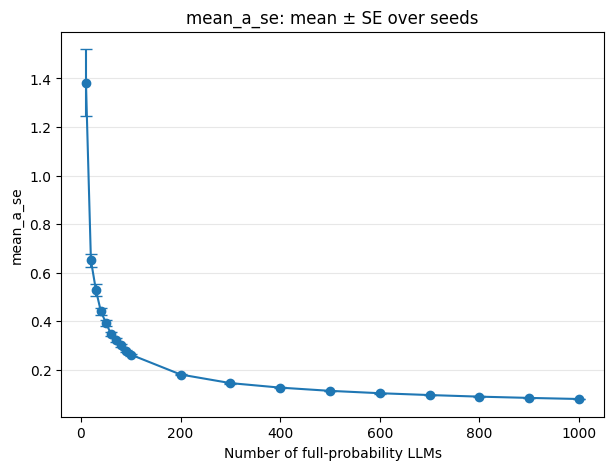

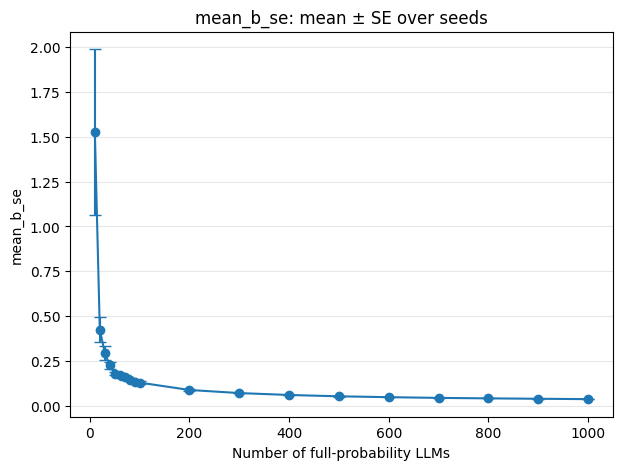

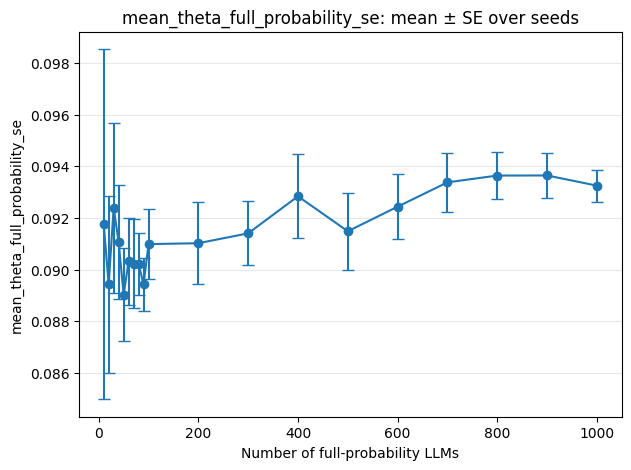

In [26]:
plot_metric_mean_se(df_summary, "mean_a_se")
plot_metric_mean_se(df_summary, "mean_b_se")
plot_metric_mean_se(df_summary, "mean_theta_full_probability_se")

In [27]:
df_raw.to_csv("260607_logprob_only_sample_size_raw.csv", index=False, encoding="utf-8-sig")
df_summary.to_csv("260607_logprob_only_sample_size_summary.csv", index=False, encoding="utf-8-sig")

In [ ]:
#binaryのみで振る
frac = 0.3#dummy
n_full_binaries =[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
rows=[]
t0=time.time()
for n_full_binary in n_full_binaries:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=n_full_binary, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
    # binaryのみ
    fit = fit_hybrid_irt_with_itemwise_mixed(
        empty_full_df, empty_full_df, sim.r_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["n_binary"] = n_full_binary
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "n_binary",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

In [28]:
def run_binary_only_sample_size_simulation(
    n_full_binaries,
    seeds=range(42, 52),
    frac=0.3,  # dummy
    n_full_probability=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    binary only 条件で、n_full_binary と seed を振ってシミュレーションする。

    Parameters
    ----------
    n_full_binaries : list
        binary-only群のLLM数。
    seeds : iterable
        seedのリスト。例: range(42, 52)
    frac : float
        dummy。simulate_itemwise_mixed_dataframesに渡すため残す。
    n_full_probability : int
        simulate関数に渡すが、fitでは使わない。
    n_mixed : int
        simulate関数に渡すが、fitでは使わない。
    n_items : int
        項目数。
    R_l : int
        logprobs反復数。binary only fitでは実質使わない。
    R_b : int
        binary反復数。
    c_tau : float
        fit関数に渡すが、binary only fitでは実質使わない。
    outer_iter : int
        outer iteration数。
    item_maxiter : int
        item optimizationの最大反復数。
    verbose : bool
        fit関数のverbose。

    Returns
    -------
    df_raw : pd.DataFrame
        n_full_binary × seed の個別結果。
    df_summary : pd.DataFrame
        n_full_binary ごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for n_full_binary in n_full_binaries:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_items,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # 空DataFrameを作成
            empty_full_df = pd.DataFrame(
                index=[],
                columns=sim.p_full_df.columns,
                dtype=float,
            )

            empty_mix_df = pd.DataFrame(
                index=[],
                columns=sim.p_mix_df.columns,
                dtype=float,
            )

            empty_mask_df = pd.DataFrame(
                index=[],
                columns=sim.mask_mix_df.columns,
                dtype=float,
            )

            # binary only:
            # full probability群 = empty
            # binary群 = sim.r_bin_df
            # mixed群 = empty
            fit = fit_hybrid_irt_with_itemwise_mixed(
                empty_full_df,
                empty_full_df,
                sim.r_bin_df,
                p_mix=empty_mix_df,
                s2_mix=empty_mix_df,
                r_mix=empty_mix_df,
                mask_mix=empty_mask_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_binary"] = n_full_binary
            row["seed"] = seed
            row["condition"] = "binary_only"
            rows.append(row)

            print(
                f"done: n_binary={n_full_binary}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_binary"):
        out = {
            "n_binary": n,
            "n_seed": g["seed"].nunique(),
            "condition": "binary_only",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("n_binary")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [29]:
n_full_binaries = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 400, 500, 600, 700, 800, 900, 1000
]

df_binary_raw, df_binary_summary = run_binary_only_sample_size_simulation(
    n_full_binaries=n_full_binaries,
    seeds=range(42, 52),  # 10 seeds
    frac=0.3,             # dummy
    n_full_probability=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
)

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=10, seed=42, converged=False


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=10, seed=43, converged=False


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=1000, seed=49, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=1000, seed=50, converged=True
done: n_binary=1000, seed=51, converged=True

Elapsed: 2672.3 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [26]:
df.to_csv("260531_simulation_binary.csv", index=False, encoding="utf-8-sig")

In [30]:
display_cols = [
    "n_binary",
    "n_seed",
    "convergence_rate",
    "mean_a_se_mean",
    "mean_a_se_se",
    "mean_b_se_mean",
    "mean_b_se_se",
    "mean_theta_binary_se_mean",
    "mean_theta_binary_se_se",
    "rmse_a_mean",
    "rmse_a_se",
    "rmse_b_mean",
    "rmse_b_se",
    "rmse_theta_binary_mean",
    "rmse_theta_binary_se",
    "n_iterations_mean",
    "final_rel_obj_change_mean",
    "final_max_param_change_mean",
]

display_cols = [c for c in display_cols if c in df_binary_summary.columns]

df_binary_summary[display_cols]

,n_binary,n_seed,convergence_rate,mean_a_se_mean,mean_a_se_se,mean_b_se_mean,mean_b_se_se,mean_theta_binary_se_mean,mean_theta_binary_se_se,rmse_a_mean,rmse_a_se,rmse_b_mean,rmse_b_se,rmse_theta_binary_mean,rmse_theta_binary_se,n_iterations_mean,final_rel_obj_change_mean,final_max_param_change_mean
0,10,10,0.0,454.050996,207.774579,120.290981,54.147195,0.069226,0.005472,1.358618,0.078816,0.888778,0.135427,0.398778,0.075594,1000.0,2.188171e-08,0.012960
1,20,10,0.3,7.828342,6.964106,2.290706,1.845188,0.068970,0.002329,0.678331,0.052238,0.462839,0.039208,0.246659,0.025705,714.0,2.487325e-09,0.001823
2,30,10,0.8,0.726442,0.284504,0.358325,0.070654,0.071747,0.001996,0.470399,0.036587,0.360486,0.040625,0.176850,0.022880,237.0,1.836099e-10,0.000524
3,40,10,1.0,0.345592,0.060831,0.207343,0.014056,0.070799,0.001556,0.332428,0.023557,0.260799,0.028972,0.164889,0.028899,29.5,9.817858e-11,0.000079
4,50,10,1.0,0.233953,0.006362,0.189997,0.014210,0.072214,0.001795,0.264447,0.014327,0.258626,0.028410,0.164388,0.020883,30.6,9.163264e-11,0.000080
5,60,10,1.0,0.210976,0.004403,0.162511,0.008316,0.072154,0.001453,0.231789,0.009101,0.217221,0.024163,0.127777,0.022245,28.8,1.162322e-10,0.000083
6,70,10,1.0,0.196778,0.003144,0.147759,0.009791,0.071874,0.001734,0.205273,0.006538,0.199609,0.016439,0.138453,0.016100,26.2,1.300407e-10,0.000086
7,80,10,1.0,0.183040,0.004440,0.138053,0.009625,0.070965,0.001304,0.200306,0.006957,0.176585,0.013400,0.120716,0.011239,28.1,1.295316e-10,0.000085
8,90,10,1.0,0.166237,0.003808,0.125763,0.007942,0.071070,0.001503,0.185894,0.008311,0.154231,0.015438,0.107239,0.006736,28.1,8.974130e-11,0.000083
9,100,10,1.0,0.157609,0.003164,0.112042,0.006356,0.071389,0.001484,0.170521,0.008941,0.141227,0.012959,0.109389,0.012475,23.9,1.181139e-10,0.000069


In [31]:
def plot_metric_mean_se(
    df_summary,
    metric,
    x_col,
    figsize=(7, 5),
):
    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se"

    if mean_col not in df_summary.columns:
        raise ValueError(f"{mean_col} が df_summary にありません。")
    if se_col not in df_summary.columns:
        raise ValueError(f"{se_col} が df_summary にありません。")

    x = df_summary[x_col]
    y = df_summary[mean_col]
    yerr = df_summary[se_col]

    plt.figure(figsize=figsize)
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel(x_col)
    plt.ylabel(metric)
    plt.title(f"{metric}: mean ± SE over seeds")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

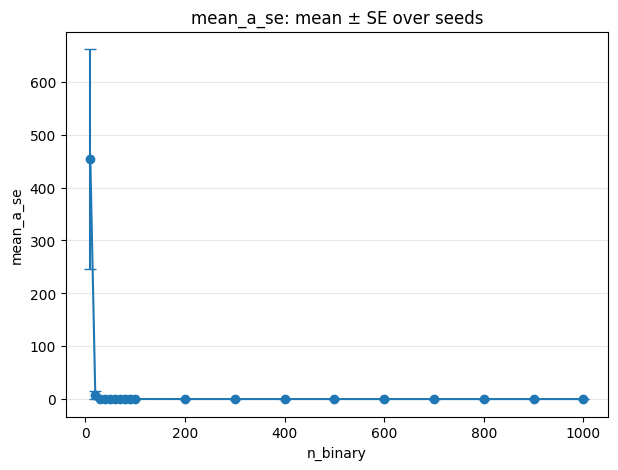

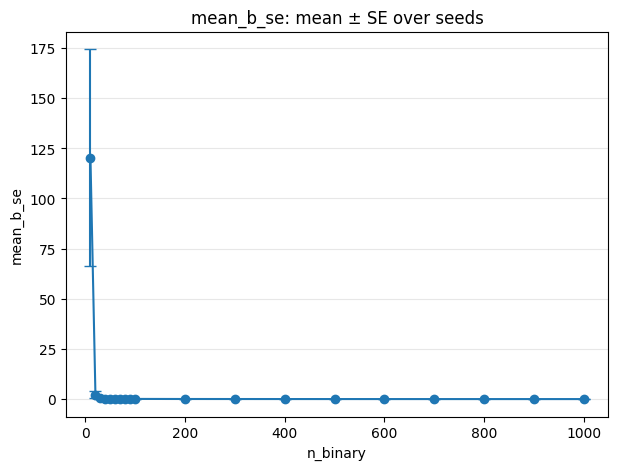

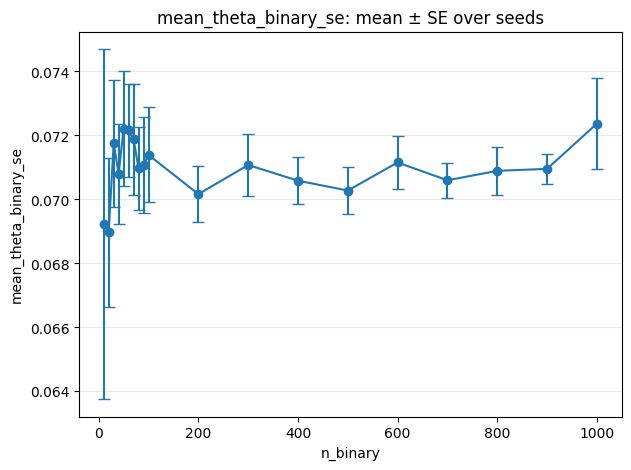

In [32]:
plot_metric_mean_se(df_binary_summary, "mean_a_se", x_col="n_binary")
plot_metric_mean_se(df_binary_summary, "mean_b_se", x_col="n_binary")
plot_metric_mean_se(df_binary_summary, "mean_theta_binary_se", x_col="n_binary")

In [33]:
df_binary_raw.to_csv(
    "260607_binary_only_sample_size_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_binary_summary.to_csv(
    "260607_binary_only_sample_size_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [27]:
#mixedなしでlogprobのみで振る
frac = 0.3#dummy
n_full_probabilities =[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
rows=[]
t0=time.time()
for n_full_probability in n_full_probabilities:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=n_full_probability, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
    # mix群なし
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["n_full_probs(mixed)"] = n_full_probability
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "n_full_probs(mixed)",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Loca


Elapsed: 243.5 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,n_full_probs(mixed),rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,10,0.254238,0.124865,0.224619,0.136770,0.042052,0.108710,NaN,0.076450,0.065754,NaN,True,27,2.424689e-10,0.000094
1,20,0.202273,0.151695,0.205134,0.126436,0.098437,0.118268,NaN,0.076973,0.070469,NaN,True,29,2.378471e-10,0.000078
2,30,0.202075,0.131663,0.190630,0.126762,0.059343,0.103332,NaN,0.077459,0.071478,NaN,True,30,9.380617e-11,0.000060
3,40,0.225666,0.119213,0.203885,0.118033,0.067312,0.096595,NaN,0.079964,0.069436,NaN,True,37,2.167538e-10,0.000094
4,50,0.137527,0.105014,0.182753,0.114520,0.059773,0.091300,NaN,0.084466,0.070626,NaN,True,36,1.926157e-10,0.000098
5,60,0.130058,0.100067,0.173130,0.110665,0.076092,0.108375,NaN,0.092344,0.067050,NaN,True,32,3.408531e-10,0.000087
6,70,0.124146,0.085923,0.169842,0.101467,0.038980,0.066011,NaN,0.090629,0.069376,NaN,True,35,3.895968e-10,0.000098
7,80,0.125809,0.072463,0.167639,0.099357,0.033455,0.059877,NaN,0.091466,0.068524,NaN,True,33,4.779432e-10,0.000100
8,90,0.182603,0.068462,0.174599,0.093476,0.034919,0.061647,NaN,0.088983,0.067452,NaN,True,38,1.257664e-10,0.000072
9,100,0.150968,0.061836,0.166748,0.088960,0.026421,0.083671,NaN,0.088187,0.067296,NaN,True,37,1.481034e-10,0.000092


In [28]:
df.to_csv("260531_simulation_integrate_prob.csv", index=False, encoding="utf-8-sig")

In [34]:
def run_no_mixed_logprob_binary_sample_size_simulation(
    n_full_probabilities,
    seeds=range(42, 52),
    frac=0.3,  # dummy
    n_full_binary=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    mixed群なしで、full probability群 + binary群のみを使う条件。
    n_full_probability と seed を振って、各seedの結果と集計結果を返す。

    Returns
    -------
    df_raw : pd.DataFrame
        n_full_probability × seed の個別結果。
    df_summary : pd.DataFrame
        n_full_probability ごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for n_full_probability in n_full_probabilities:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_items,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # mixed群を空にする
            empty_mix_df = pd.DataFrame(
                index=[],
                columns=sim.p_mix_df.columns,
                dtype=float,
            )

            empty_mask_df = pd.DataFrame(
                index=[],
                columns=sim.mask_mix_df.columns,
                dtype=float,
            )

            # mixed群なし：
            # full probability群 = sim.p_full_df, sim.s2_full_df
            # binary群 = sim.r_bin_df
            # mixed群 = empty
            fit = fit_hybrid_irt_with_itemwise_mixed(
                sim.p_full_df,
                sim.s2_full_df,
                sim.r_bin_df,
                p_mix=empty_mix_df,
                s2_mix=empty_mix_df,
                r_mix=empty_mix_df,
                mask_mix=empty_mask_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_full_probs"] = n_full_probability
            row["seed"] = seed
            row["condition"] = "no_mixed_full_prob_plus_binary"
            rows.append(row)

            print(
                f"done: n_full_probability={n_full_probability}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_full_probs"):
        out = {
            "n_full_probs": n,
            "n_seed": g["seed"].nunique(),
            "condition": "no_mixed_full_prob_plus_binary",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("n_full_probs")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [35]:
n_full_probabilities = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 400, 500, 600, 700, 800, 900, 1000
]

df_no_mixed_raw, df_no_mixed_summary = run_no_mixed_logprob_binary_sample_size_simulation(
    n_full_probabilities=n_full_probabilities,
    seeds=range(42, 52),  # 10 seeds
    frac=0.3,             # dummy
    n_full_binary=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
)

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=10, seed=42, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=10, seed=43, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=1000, seed=49, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_full_probability=1000, seed=50, converged=True
done: n_full_probability=1000, seed=51, converged=True

Elapsed: 3086.5 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [36]:
display_cols = [
    "n_full_probs",
    "n_seed",
    "convergence_rate",
    "mean_a_se_mean",
    "mean_a_se_se",
    "mean_b_se_mean",
    "mean_b_se_se",
    "mean_theta_full_probability_se_mean",
    "mean_theta_full_probability_se_se",
    "mean_theta_binary_se_mean",
    "mean_theta_binary_se_se",
    "rmse_a_mean",
    "rmse_a_se",
    "rmse_b_mean",
    "rmse_b_se",
    "rmse_theta_full_probability_mean",
    "rmse_theta_full_probability_se",
    "rmse_theta_binary_mean",
    "rmse_theta_binary_se",
]

display_cols = [c for c in display_cols if c in df_no_mixed_summary.columns]

df_no_mixed_summary[display_cols]

,n_full_probs,n_seed,convergence_rate,mean_a_se_mean,mean_a_se_se,mean_b_se_mean,mean_b_se_se,mean_theta_full_probability_se_mean,mean_theta_full_probability_se_se,mean_theta_binary_se_mean,mean_theta_binary_se_se,rmse_a_mean,rmse_a_se,rmse_b_mean,rmse_b_se,rmse_theta_full_probability_mean,rmse_theta_full_probability_se,rmse_theta_binary_mean,rmse_theta_binary_se
0,10,10,0.9,0.244542,0.013929,0.148347,0.007838,0.080355,0.002373,0.068526,0.000984,0.286164,0.029358,0.170090,0.015039,0.091688,0.017678,0.123525,0.015159
1,20,10,1.0,0.257648,0.023095,0.135679,0.006301,0.081940,0.001539,0.070412,0.001312,0.281614,0.025635,0.157953,0.012867,0.100657,0.014707,0.132504,0.014033
2,30,10,1.0,0.223300,0.007734,0.135227,0.007650,0.088948,0.004867,0.068820,0.001478,0.231116,0.010642,0.148898,0.009903,0.090318,0.009598,0.115009,0.009717
3,40,10,1.0,0.208288,0.004517,0.129139,0.007827,0.090278,0.004655,0.068926,0.001062,0.218451,0.009498,0.140315,0.012954,0.069357,0.011076,0.100539,0.007629
4,50,10,1.0,0.196919,0.004085,0.118353,0.004833,0.091529,0.003094,0.068957,0.001011,0.189784,0.009882,0.114865,0.012075,0.067095,0.011640,0.098292,0.007293
5,60,10,1.0,0.190078,0.004700,0.113886,0.005393,0.090477,0.002257,0.070575,0.001862,0.178553,0.014857,0.117708,0.012212,0.075764,0.014694,0.104995,0.012736
6,70,10,1.0,0.188941,0.005503,0.109401,0.005410,0.091050,0.002084,0.069201,0.001278,0.173090,0.014855,0.109026,0.009977,0.064768,0.011026,0.090621,0.009877
7,80,10,1.0,0.178502,0.004444,0.103807,0.004366,0.089836,0.001733,0.070067,0.001458,0.160003,0.010022,0.092750,0.007048,0.057747,0.007986,0.087023,0.006126
8,90,10,1.0,0.174013,0.004531,0.099906,0.004316,0.089211,0.001405,0.070686,0.001643,0.156468,0.010155,0.085719,0.007407,0.055461,0.007798,0.084315,0.005508
9,100,10,1.0,0.174646,0.003466,0.096284,0.004528,0.089157,0.002195,0.072671,0.003322,0.157419,0.007229,0.082247,0.005028,0.051043,0.005471,0.090587,0.005869


In [37]:
def plot_metric_mean_se(
    df_summary,
    metric,
    x_col="n_full_probs",
    figsize=(7, 5),
):
    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se"

    if mean_col not in df_summary.columns:
        raise ValueError(f"{mean_col} が df_summary にありません。")
    if se_col not in df_summary.columns:
        raise ValueError(f"{se_col} が df_summary にありません。")

    x = df_summary[x_col]
    y = df_summary[mean_col]
    yerr = df_summary[se_col]

    plt.figure(figsize=figsize)
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel("Number of full-probability LLMs")
    plt.ylabel(metric)
    plt.title(f"{metric}: mean ± SE over seeds")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

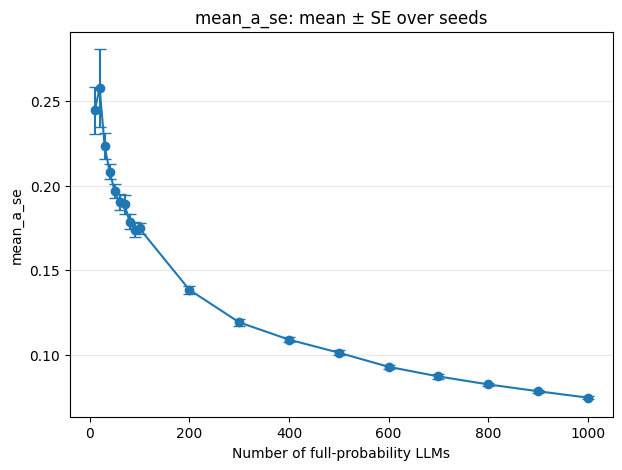

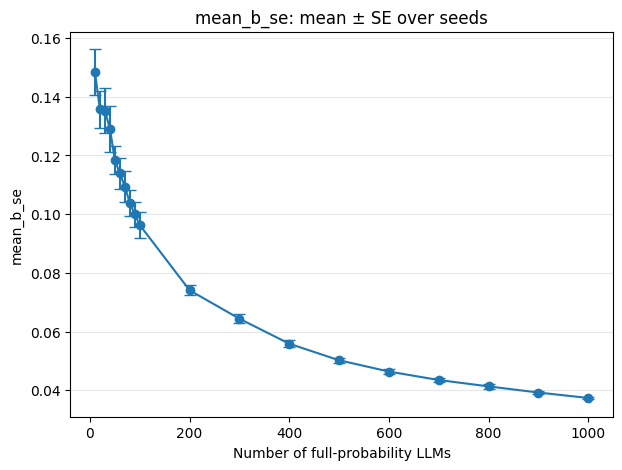

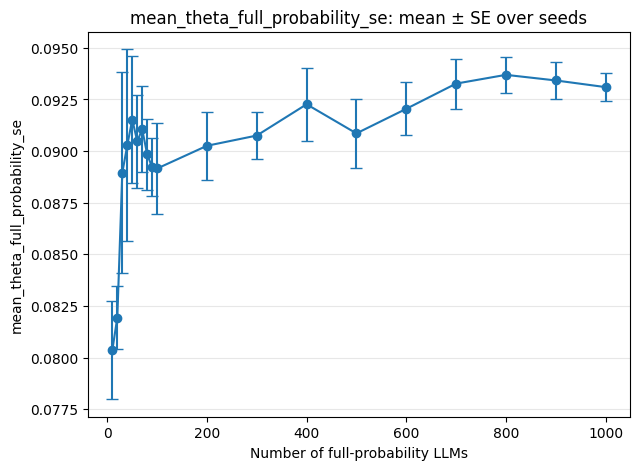

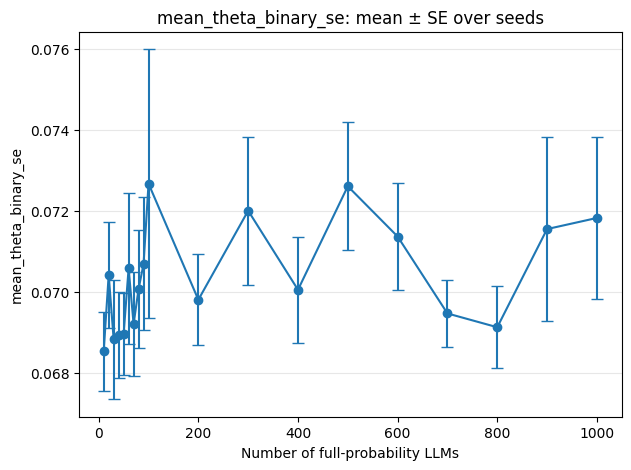

In [38]:
plot_metric_mean_se(df_no_mixed_summary, "mean_a_se")
plot_metric_mean_se(df_no_mixed_summary, "mean_b_se")
plot_metric_mean_se(df_no_mixed_summary, "mean_theta_full_probability_se")
plot_metric_mean_se(df_no_mixed_summary, "mean_theta_binary_se")

In [39]:
df_no_mixed_raw.to_csv(
    "260607_no_mixed_logprob_binary_sample_size_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_no_mixed_summary.to_csv(
    "260607_no_mixed_logprob_binary_sample_size_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [29]:
#binaryのみで振る
frac = 0.3#dummy
n_full_binaries =[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
rows=[]
t0=time.time()
for n_full_binary in n_full_binaries:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=n_full_binary, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # sim の item columns だけ使って、0行DataFrameを作る

    empty_full_df = pd.DataFrame(index=[], columns=sim.p_full_df.columns, dtype=float)
    empty_bin_df = pd.DataFrame(index=[], columns=sim.r_bin_df.columns, dtype=float)    
    empty_mix_df = pd.DataFrame(index=[], columns=sim.p_mix_df.columns, dtype=float)
    empty_mask_df = pd.DataFrame(index=[], columns=sim.mask_mix_df.columns, dtype=float)

    
    # mix群なし
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
        p_mix=empty_mix_df,
        s2_mix=empty_mix_df,
        r_mix=empty_mix_df,
        mask_mix=empty_mask_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    row["n_binary(mixed)"] = n_full_binary
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "n_binary(mixed)",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]
df[display_cols]

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Loca


Elapsed: 175.5 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,n_binary(mixed),rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,10,0.255768,0.105442,0.321623,0.132012,0.078950,0.150945,NaN,0.078459,0.071836,NaN,True,47,7.536179e-10,0.000094
1,20,0.192146,0.128558,0.253599,0.139680,0.102579,0.114985,NaN,0.081258,0.071469,NaN,True,46,2.926754e-10,0.000065
2,30,0.224260,0.123410,0.248036,0.129088,0.080056,0.101218,NaN,0.082012,0.074928,NaN,True,45,2.219630e-10,0.000063
3,40,0.197393,0.100720,0.206058,0.119890,0.069003,0.068853,NaN,0.081517,0.069868,NaN,True,41,8.855302e-11,0.000083
4,50,0.137527,0.105014,0.182753,0.114520,0.059773,0.091300,NaN,0.084466,0.070626,NaN,True,36,1.926157e-10,0.000098
5,60,0.157776,0.127136,0.174924,0.105121,0.091644,0.119252,NaN,0.083680,0.071845,NaN,True,35,2.093219e-10,0.000076
6,70,0.158183,0.077187,0.163047,0.101093,0.040150,0.083500,NaN,0.083264,0.069712,NaN,True,32,2.379345e-10,0.000075
7,80,0.148510,0.089209,0.154630,0.097412,0.026842,0.071868,NaN,0.084439,0.069007,NaN,True,31,1.446477e-10,0.000073
8,90,0.145560,0.081670,0.146700,0.094068,0.029115,0.072926,NaN,0.083222,0.069385,NaN,True,28,3.402180e-10,0.000095
9,100,0.148700,0.081888,0.141698,0.084903,0.028222,0.071247,NaN,0.082417,0.069426,NaN,True,30,1.681479e-10,0.000099


In [30]:
df.to_csv("260531_simulation_integrate_binary.csv", index=False, encoding="utf-8-sig")

In [40]:
def run_no_mixed_vary_binary_sample_size_simulation(
    n_full_binaries,
    seeds=range(42, 52),
    frac=0.3,  # dummy
    n_full_probability=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    mixed群なしで、full probability群 + binary群を使う条件。
    n_full_binary を変え、seedも複数振ってシミュレーションする。

    ここでは、
      - full probability群: sim.p_full_df, sim.s2_full_df
      - binary群: sim.r_bin_df
      - mixed群: 空
    をfitに渡す。

    Returns
    -------
    df_raw : pd.DataFrame
        n_full_binary × seed の個別結果。
    df_summary : pd.DataFrame
        n_full_binaryごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for n_full_binary in n_full_binaries:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_items,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # mixed群を空にする
            empty_mix_df = pd.DataFrame(
                index=[],
                columns=sim.p_mix_df.columns,
                dtype=float,
            )

            empty_mask_df = pd.DataFrame(
                index=[],
                columns=sim.mask_mix_df.columns,
                dtype=float,
            )

            # mixed群なし:
            # full probability群 + binary群のみ
            fit = fit_hybrid_irt_with_itemwise_mixed(
                sim.p_full_df,
                sim.s2_full_df,
                sim.r_bin_df,
                p_mix=empty_mix_df,
                s2_mix=empty_mix_df,
                r_mix=empty_mix_df,
                mask_mix=empty_mask_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_binary"] = n_full_binary
            row["seed"] = seed
            row["condition"] = "no_mixed_full_probability_plus_binary"
            rows.append(row)

            print(
                f"done: n_binary={n_full_binary}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    # 実際に存在する列だけ使う
    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_binary"):
        out = {
            "n_binary": n,
            "n_seed": g["seed"].nunique(),
            "condition": "no_mixed_full_probability_plus_binary",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("n_binary")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [41]:
n_full_binaries = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 400, 500, 600, 700, 800, 900, 1000
]

df_no_mixed_vary_binary_raw, df_no_mixed_vary_binary_summary = (
    run_no_mixed_vary_binary_sample_size_simulation(
        n_full_binaries=n_full_binaries,
        seeds=range(42, 52),  # 10 seeds
        frac=0.3,             # dummy
        n_full_probability=50,
        n_mixed=50,
        n_items=100,
        R_l=5,
        R_b=5,
        c_tau=0.25,
        outer_iter=1000,
        item_maxiter=1000,
        verbose=False,
    )
)

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=10, seed=42, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=10, seed=43, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=1000, seed=49, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_binary=1000, seed=50, converged=True
done: n_binary=1000, seed=51, converged=True

Elapsed: 2051.0 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [42]:
display_cols = [
    "n_binary",
    "n_seed",
    "convergence_rate",
    "mean_a_se_mean",
    "mean_a_se_se",
    "mean_b_se_mean",
    "mean_b_se_se",
    "mean_theta_full_probability_se_mean",
    "mean_theta_full_probability_se_se",
    "mean_theta_binary_se_mean",
    "mean_theta_binary_se_se",
    "rmse_a_mean",
    "rmse_a_se",
    "rmse_b_mean",
    "rmse_b_se",
    "rmse_theta_full_probability_mean",
    "rmse_theta_full_probability_se",
    "rmse_theta_binary_mean",
    "rmse_theta_binary_se",
    "n_iterations_mean",
    "final_rel_obj_change_mean",
    "final_max_param_change_mean",
]

display_cols = [
    c for c in display_cols
    if c in df_no_mixed_vary_binary_summary.columns
]

df_no_mixed_vary_binary_summary[display_cols]

,n_binary,n_seed,convergence_rate,mean_a_se_mean,mean_a_se_se,mean_b_se_mean,mean_b_se_se,mean_theta_full_probability_se_mean,mean_theta_full_probability_se_se,mean_theta_binary_se_mean,...,rmse_a_se,rmse_b_mean,rmse_b_se,rmse_theta_full_probability_mean,rmse_theta_full_probability_se,rmse_theta_binary_mean,rmse_theta_binary_se,n_iterations_mean,final_rel_obj_change_mean,final_max_param_change_mean
0,10,10,1.0,0.376540,0.035833,0.160194,0.008611,0.087896,0.002264,0.068226,...,0.036024,0.131872,0.016912,0.097881,0.017855,0.123928,0.014513,49.3,4.941919e-10,0.000086
1,20,10,1.0,0.289429,0.008142,0.143961,0.006948,0.088397,0.002984,0.068690,...,0.016802,0.140656,0.015331,0.103406,0.017993,0.125733,0.014005,39.8,2.378760e-10,0.000075
2,30,10,1.0,0.266573,0.014145,0.136692,0.006243,0.090084,0.003024,0.069418,...,0.015936,0.134454,0.010745,0.096988,0.009902,0.108451,0.008626,38.3,1.644116e-10,0.000077
3,40,10,1.0,0.218758,0.004464,0.122379,0.004361,0.089437,0.002912,0.068408,...,0.010767,0.114187,0.008601,0.070762,0.010265,0.094927,0.007996,34.1,1.563138e-10,0.000074
4,50,10,1.0,0.196919,0.004085,0.118353,0.004833,0.091529,0.003094,0.068957,...,0.009882,0.114865,0.012075,0.067095,0.011640,0.098292,0.007293,32.4,1.898801e-10,0.000076
5,60,10,1.0,0.180380,0.002815,0.112395,0.003814,0.091082,0.003320,0.069807,...,0.005475,0.125746,0.014188,0.077799,0.016269,0.101003,0.011993,31.3,2.005767e-10,0.000080
6,70,10,1.0,0.171645,0.003118,0.106705,0.005404,0.090131,0.002743,0.069728,...,0.007728,0.114344,0.009164,0.064994,0.011006,0.094690,0.009188,30.2,1.502296e-10,0.000081
7,80,10,1.0,0.162474,0.003381,0.102327,0.004728,0.090505,0.002787,0.069241,...,0.004588,0.102449,0.007604,0.058917,0.008392,0.087276,0.006039,30.5,1.393896e-10,0.000079
8,90,10,1.0,0.151015,0.002836,0.096914,0.003948,0.089372,0.002270,0.069557,...,0.006870,0.100018,0.008581,0.053780,0.006413,0.086835,0.005689,29.1,1.425418e-10,0.000079
9,100,10,1.0,0.144292,0.002441,0.090272,0.004025,0.089748,0.002640,0.070097,...,0.007070,0.091023,0.004162,0.050228,0.004325,0.082756,0.003826,26.2,1.934833e-10,0.000084


In [43]:
def plot_metric_mean_se(
    df_summary,
    metric,
    x_col,
    figsize=(7, 5),
):
    """
    df_summaryから metric_mean ± metric_se をプロットする。
    """

    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se"

    if mean_col not in df_summary.columns:
        raise ValueError(f"{mean_col} が df_summary にありません。")
    if se_col not in df_summary.columns:
        raise ValueError(f"{se_col} が df_summary にありません。")

    x = df_summary[x_col]
    y = df_summary[mean_col]
    yerr = df_summary[se_col]

    plt.figure(figsize=figsize)
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel(x_col)
    plt.ylabel(metric)
    plt.title(f"{metric}: mean ± SE over seeds")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

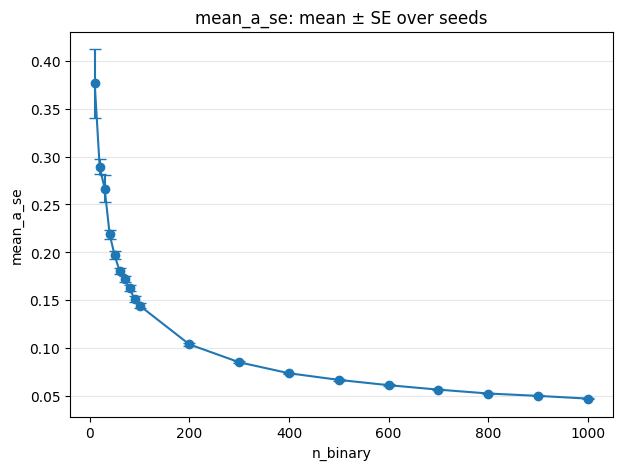

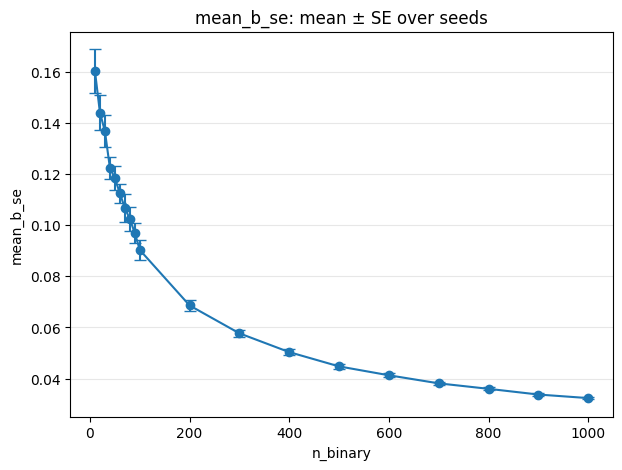

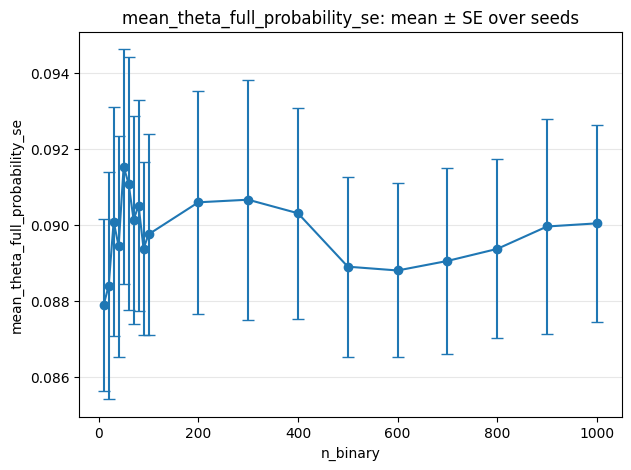

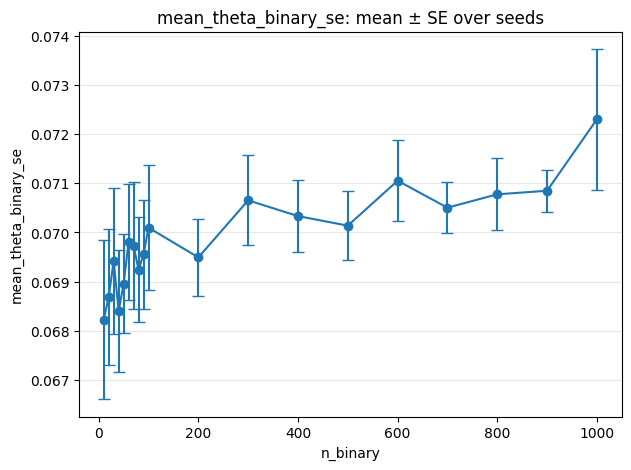

In [44]:
plot_metric_mean_se(
    df_no_mixed_vary_binary_summary,
    "mean_a_se",
    x_col="n_binary",
)

plot_metric_mean_se(
    df_no_mixed_vary_binary_summary,
    "mean_b_se",
    x_col="n_binary",
)

plot_metric_mean_se(
    df_no_mixed_vary_binary_summary,
    "mean_theta_full_probability_se",
    x_col="n_binary",
)

plot_metric_mean_se(
    df_no_mixed_vary_binary_summary,
    "mean_theta_binary_se",
    x_col="n_binary",
)

In [45]:
df_no_mixed_vary_binary_raw.to_csv(
    "260607_no_mixed_vary_binary_sample_size_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_no_mixed_vary_binary_summary.to_csv(
    "260607_no_mixed_vary_binary_sample_size_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [31]:
#mixedだけで振る
fractions = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
rows=[]
t0=time.time()
for frac in fractions:
    
    sim=simulate_itemwise_mixed_dataframes(
        n_full_probability=50, n_full_binary=50, n_mixed=50,
        n_items=100, R_l=5, R_b=5, binary_fraction=frac, seed=42
    )

    # mix群あり
    fit = fit_hybrid_irt_with_itemwise_mixed(
        sim.p_full_df, sim.s2_full_df, sim.r_bin_df,
        sim.p_mix_df, sim.s2_mix_df, sim.r_mix_df, sim.mask_mix_df,
        R_l=sim.R_l, R_b=sim.R_b, c_tau=0.25,
        outer_iter=1000, item_maxiter=1000, verbose=False
    )
    row = summarize_result(fit, sim)
    rows.append(row)
    
df=pd.DataFrame(rows)
print(f"\nElapsed: {time.time()-t0:.1f} sec")
display_cols = [
    "binary_fraction_target",
    "binary_fraction_actual",
    "rmse_a",
    "rmse_b",
    "mean_a_se",
    "mean_b_se",
    "rmse_theta_full_probability",
    "rmse_theta_binary",
    "rmse_theta_mixed",
    "mean_theta_full_probability_se",
    "mean_theta_binary_se",
    "mean_theta_mixed_se",
    "converged",
    "n_iterations",
    "final_rel_obj_change",
    "final_max_param_change",
]

df[display_cols]


Elapsed: 161.7 sec


,binary_fraction_target,binary_fraction_actual,rmse_a,rmse_b,mean_a_se,mean_b_se,rmse_theta_full_probability,rmse_theta_binary,rmse_theta_mixed,mean_theta_full_probability_se,mean_theta_binary_se,mean_theta_mixed_se,converged,n_iterations,final_rel_obj_change,final_max_param_change
0,0.05,0.0458,0.102657,0.061509,0.126127,0.076082,0.020159,0.072477,0.037750,0.083732,0.069728,0.052954,True,31,2.651210e-10,0.000097
1,0.10,0.0962,0.103217,0.062160,0.126626,0.076523,0.020162,0.072458,0.038133,0.083711,0.069713,0.053527,True,31,2.103377e-10,0.000100
2,0.15,0.1446,0.104583,0.062584,0.127211,0.076972,0.020164,0.072512,0.039862,0.083698,0.069687,0.054215,True,33,1.155263e-10,0.000039
3,0.20,0.1912,0.105379,0.064511,0.127976,0.077709,0.020210,0.072471,0.041046,0.083706,0.069672,0.054932,True,31,1.753144e-10,0.000069
4,0.25,0.2438,0.106481,0.065036,0.128586,0.078176,0.020179,0.072507,0.041624,0.083675,0.069657,0.055582,True,31,1.551803e-10,0.000055
5,0.30,0.2944,0.106708,0.065679,0.128954,0.078695,0.020167,0.072538,0.042282,0.083673,0.069654,0.056158,True,31,1.507501e-10,0.000057
6,0.35,0.3492,0.107635,0.066931,0.129424,0.079350,0.020254,0.072510,0.042950,0.083701,0.069666,0.056821,True,30,2.268545e-10,0.000088
7,0.40,0.3970,0.108447,0.068746,0.129837,0.079922,0.020455,0.072504,0.043443,0.083709,0.069668,0.057458,True,31,1.440701e-10,0.000070
8,0.45,0.4482,0.109163,0.069729,0.130307,0.080661,0.020386,0.072450,0.044578,0.083710,0.069647,0.058133,True,31,1.403546e-10,0.000079
9,0.50,0.4962,0.109816,0.070413,0.130783,0.081058,0.020422,0.072476,0.045824,0.083699,0.069635,0.058802,True,32,1.164548e-10,0.000047


In [32]:
df.to_csv("260531_simulation_mixed.csv", index=False, encoding="utf-8-sig")

In [46]:
def run_mixed_fraction_simulation(
    fractions,
    seeds=range(42, 52),
    n_full_probability=50,
    n_full_binary=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    mixed群ありで、binary_fraction と seed を振ってシミュレーションする。

    Parameters
    ----------
    fractions : list
        mixed群における binary-only cell の割合。
    seeds : iterable
        seedのリスト。例: range(42, 52)
    n_full_probability : int
        full probability群のLLM数。
    n_full_binary : int
        binary-only群のLLM数。
    n_mixed : int
        mixed群のLLM数。
    n_items : int
        項目数。
    R_l : int
        logprobs反復数。
    R_b : int
        binary反復数。
    c_tau : float
        tau^2 = c_tau / R_l の係数。
    outer_iter : int
        outer iteration数。
    item_maxiter : int
        item optimizationの最大反復数。
    verbose : bool
        fit関数のverbose。

    Returns
    -------
    df_raw : pd.DataFrame
        fraction × seed の個別結果。
    df_summary : pd.DataFrame
        fractionごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for frac in fractions:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_items,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # mixed群あり
            fit = fit_hybrid_irt_with_itemwise_mixed(
                sim.p_full_df,
                sim.s2_full_df,
                sim.r_bin_df,
                p_mix=sim.p_mix_df,
                s2_mix=sim.s2_mix_df,
                r_mix=sim.r_mix_df,
                mask_mix=sim.mask_mix_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["binary_fraction_target"] = frac
            row["seed"] = seed
            row["condition"] = "mixed"
            rows.append(row)

            print(
                f"done: frac={frac:.2f}, "
                f"seed={seed}, "
                f"actual={row.get('binary_fraction_actual', np.nan):.3f}, "
                f"converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "binary_fraction_actual",
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for frac, g in df_raw.groupby("binary_fraction_target"):
        out = {
            "binary_fraction_target": frac,
            "n_seed": g["seed"].nunique(),
            "condition": "mixed",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

            # 経験的95%範囲も付けておく
            out[f"{m}_q025"] = x.quantile(0.025) if len(x) > 0 else np.nan
            out[f"{m}_q975"] = x.quantile(0.975) if len(x) > 0 else np.nan

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("binary_fraction_target")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [47]:
fractions = [
    0.05, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50,
    0.55, 0.60, 0.65, 0.70, 0.75,
    0.80, 0.85, 0.90, 0.95,
]

df_mixed_raw, df_mixed_summary = run_mixed_fraction_simulation(
    fractions=fractions,
    seeds=range(42, 52),  # 10 seeds
    n_full_probability=50,
    n_full_binary=50,
    n_mixed=50,
    n_items=100,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
)

done: frac=0.05, seed=42, actual=0.046, converged=True
done: frac=0.05, seed=43, actual=0.045, converged=True
done: frac=0.05, seed=44, actual=0.051, converged=True
done: frac=0.05, seed=45, actual=0.046, converged=True
done: frac=0.05, seed=46, actual=0.047, converged=True
done: frac=0.05, seed=47, actual=0.048, converged=True
done: frac=0.05, seed=48, actual=0.052, converged=True
done: frac=0.05, seed=49, actual=0.056, converged=True
done: frac=0.05, seed=50, actual=0.053, converged=True
done: frac=0.05, seed=51, actual=0.052, converged=True
done: frac=0.10, seed=42, actual=0.096, converged=True
done: frac=0.10, seed=43, actual=0.093, converged=True
done: frac=0.10, seed=44, actual=0.102, converged=True
done: frac=0.10, seed=45, actual=0.097, converged=True
done: frac=0.10, seed=46, actual=0.095, converged=True
done: frac=0.10, seed=47, actual=0.100, converged=True
done: frac=0.10, seed=48, actual=0.105, converged=True
done: frac=0.10, seed=49, actual=0.108, converged=True
done: frac

In [48]:
display_cols = [
    "binary_fraction_target",
    "n_seed",
    "convergence_rate",
    "binary_fraction_actual_mean",
    "binary_fraction_actual_se",
    "rmse_a_mean",
    "rmse_a_se",
    "rmse_b_mean",
    "rmse_b_se",
    "mean_a_se_mean",
    "mean_a_se_se",
    "mean_b_se_mean",
    "mean_b_se_se",
    "rmse_theta_full_probability_mean",
    "rmse_theta_full_probability_se",
    "rmse_theta_binary_mean",
    "rmse_theta_binary_se",
    "rmse_theta_mixed_mean",
    "rmse_theta_mixed_se",
    "mean_theta_full_probability_se_mean",
    "mean_theta_full_probability_se_se",
    "mean_theta_binary_se_mean",
    "mean_theta_binary_se_se",
    "mean_theta_mixed_se_mean",
    "mean_theta_mixed_se_se",
    "n_iterations_mean",
    "final_rel_obj_change_mean",
    "final_max_param_change_mean",
]

display_cols = [c for c in display_cols if c in df_mixed_summary.columns]

df_mixed_summary[display_cols]

,binary_fraction_target,n_seed,convergence_rate,binary_fraction_actual_mean,binary_fraction_actual_se,rmse_a_mean,rmse_a_se,rmse_b_mean,rmse_b_se,mean_a_se_mean,...,rmse_theta_mixed_se,mean_theta_full_probability_se_mean,mean_theta_full_probability_se_se,mean_theta_binary_se_mean,mean_theta_binary_se_se,mean_theta_mixed_se_mean,mean_theta_mixed_se_se,n_iterations_mean,final_rel_obj_change_mean,final_max_param_change_mean
0,0.05,10,1.0,0.04958,0.001168,0.119281,0.005889,0.067781,0.005046,0.133394,...,0.002294,0.090771,0.002672,0.069225,0.001499,0.055393,0.001125,30.5,2.109942e-10,0.000084
1,0.10,10,1.0,0.10002,0.001538,0.120140,0.005985,0.068427,0.005030,0.133904,...,0.002315,0.090781,0.002679,0.069221,0.001501,0.055960,0.001125,30.7,1.829631e-10,0.000083
2,0.15,10,1.0,0.14912,0.001476,0.120901,0.006027,0.069168,0.005034,0.134439,...,0.002245,0.090781,0.002683,0.069207,0.001501,0.056577,0.001133,29.9,2.246471e-10,0.000079
3,0.20,10,1.0,0.19926,0.002170,0.121791,0.005903,0.070497,0.005333,0.135017,...,0.002218,0.090787,0.002689,0.069196,0.001501,0.057208,0.001143,29.7,1.903254e-10,0.000082
4,0.25,10,1.0,0.24924,0.002273,0.122621,0.005924,0.071185,0.005447,0.135508,...,0.002308,0.090766,0.002687,0.069185,0.001501,0.057762,0.001138,29.9,2.047848e-10,0.000078
5,0.30,10,1.0,0.30058,0.002851,0.123164,0.005939,0.071882,0.005541,0.135973,...,0.002321,0.090779,0.002698,0.069178,0.001502,0.058328,0.001134,29.8,2.076122e-10,0.000074
6,0.35,10,1.0,0.35104,0.002822,0.123935,0.006041,0.072786,0.005426,0.136477,...,0.002357,0.090791,0.002700,0.069174,0.001503,0.058984,0.001137,29.3,1.881850e-10,0.000084
7,0.40,10,1.0,0.40182,0.002264,0.124938,0.006137,0.073536,0.005452,0.136926,...,0.002383,0.090785,0.002699,0.069171,0.001503,0.059606,0.001120,30.0,2.169448e-10,0.000079
8,0.45,10,1.0,0.45138,0.002667,0.125913,0.006124,0.074278,0.005406,0.137414,...,0.002375,0.090795,0.002702,0.069160,0.001505,0.060272,0.001128,29.9,1.831676e-10,0.000080
9,0.50,10,1.0,0.49992,0.002474,0.126675,0.006140,0.075343,0.005642,0.137903,...,0.002378,0.090806,0.002708,0.069154,0.001509,0.060957,0.001132,29.5,1.600836e-10,0.000076


In [49]:
def plot_metric_mean_se(
    df_summary,
    metric,
    x_col="binary_fraction_target",
    figsize=(7, 5),
):
    """
    df_summaryから metric_mean ± metric_se をプロットする。
    """

    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se"

    if mean_col not in df_summary.columns:
        raise ValueError(f"{mean_col} が df_summary にありません。")
    if se_col not in df_summary.columns:
        raise ValueError(f"{se_col} が df_summary にありません。")

    x = df_summary[x_col]
    y = df_summary[mean_col]
    yerr = df_summary[se_col]

    plt.figure(figsize=figsize)
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel(x_col)
    plt.ylabel(metric)
    plt.title(f"{metric}: mean ± SE over seeds")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

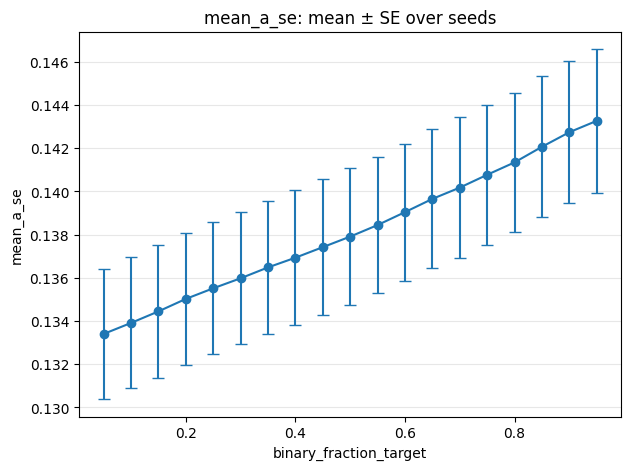

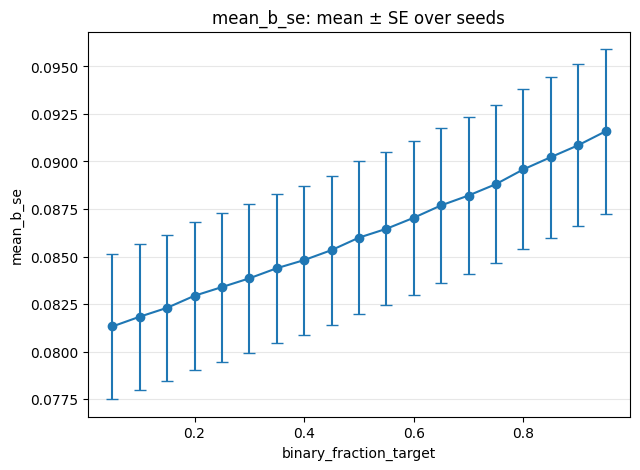

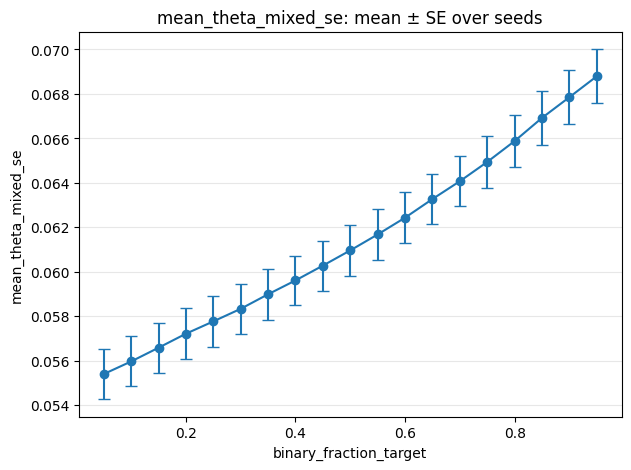

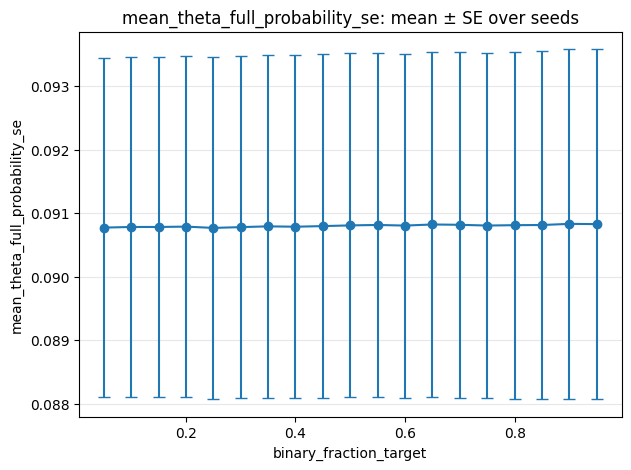

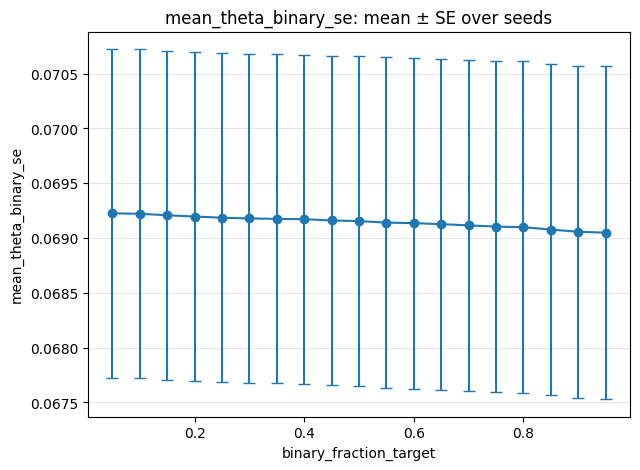

In [50]:
plot_metric_mean_se(df_mixed_summary, "mean_a_se")
plot_metric_mean_se(df_mixed_summary, "mean_b_se")
plot_metric_mean_se(df_mixed_summary, "mean_theta_mixed_se")
plot_metric_mean_se(df_mixed_summary, "mean_theta_full_probability_se")
plot_metric_mean_se(df_mixed_summary, "mean_theta_binary_se")

In [51]:
df_mixed_raw.to_csv(
    "260607_mixed_fraction_simulation_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_mixed_summary.to_csv(
    "260607_mixed_fraction_simulation_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [64]:
# binaryだけで問題数を振る
def run_binary_only_items_simulation(
    n_items,
    n_full_binary=50,
    seeds=range(42, 52),
    frac=0.3,  # dummy
    n_full_probability=50,
    n_mixed=50,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    binary only 条件で、n_items と seed を振ってシミュレーションする。

    Parameters
    ----------
    n_full_binaries : int
        binary-only群のLLM数。
    seeds : iterable
        seedのリスト。例: range(42, 52)
    frac : float
        dummy。simulate_itemwise_mixed_dataframesに渡すため残す。
    n_full_probability : int
        simulate関数に渡すが、fitでは使わない。
    n_mixed : int
        simulate関数に渡すが、fitでは使わない。
    n_items : list
        項目数。
    R_l : int
        logprobs反復数。binary only fitでは実質使わない。
    R_b : int
        binary反復数。
    c_tau : float
        fit関数に渡すが、binary only fitでは実質使わない。
    outer_iter : int
        outer iteration数。
    item_maxiter : int
        item optimizationの最大反復数。
    verbose : bool
        fit関数のverbose。

    Returns
    -------
    df_raw : pd.DataFrame
        n_full_binary × seed の個別結果。
    df_summary : pd.DataFrame
        n_full_binary ごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for n_item in n_items:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_item,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # 空DataFrameを作成
            empty_full_df = pd.DataFrame(
                index=[],
                columns=sim.p_full_df.columns,
                dtype=float,
            )

            empty_mix_df = pd.DataFrame(
                index=[],
                columns=sim.p_mix_df.columns,
                dtype=float,
            )

            empty_mask_df = pd.DataFrame(
                index=[],
                columns=sim.mask_mix_df.columns,
                dtype=float,
            )

            # binary only:
            # full probability群 = empty
            # binary群 = sim.r_bin_df
            # mixed群 = empty
            fit = fit_hybrid_irt_with_itemwise_mixed(
                empty_full_df,
                empty_full_df,
                sim.r_bin_df,
                p_mix=empty_mix_df,
                s2_mix=empty_mix_df,
                r_mix=empty_mix_df,
                mask_mix=empty_mask_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_items"] = n_item
            row["seed"] = seed
            row["condition"] = "binary_only"
            rows.append(row)

            print(
                f"done: n_items={n_item}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_items"):
        out = {
            "n_items": n,
            "n_seed": g["seed"].nunique(),
            "condition": "binary_only",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("n_items")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [68]:
n_items = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    150, 200, 250, 300, 350, 400, 450, 500
]

df_no_mixed_vary_binary_raw, df_no_mixed_vary_binary_summary = (
    run_binary_only_items_simulation(
        n_full_binary=100,
        seeds=range(42, 52),  # 10 seeds
        frac=0.3,             # dummy
        n_full_probability=100,
        n_mixed=50,
        n_items=n_items,
        R_l=5,
        R_b=5,
        c_tau=0.25,
        outer_iter=1000,
        item_maxiter=1000,
        verbose=False,
    )
)

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=10, seed=42, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=10, seed=43, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=500, seed=49, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=500, seed=50, converged=True
done: n_items=500, seed=51, converged=True

Elapsed: 926.9 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [69]:
df_no_mixed_vary_binary_summary

,n_items,n_seed,condition,convergence_rate,mean_a_se_mean,mean_a_se_sd,mean_a_se_se,mean_a_se_n,mean_b_se_mean,mean_b_se_sd,...,n_iterations_se,n_iterations_n,final_rel_obj_change_mean,final_rel_obj_change_sd,final_rel_obj_change_se,final_rel_obj_change_n,final_max_param_change_mean,final_max_param_change_sd,final_max_param_change_se,final_max_param_change_n
0,10,10,binary_only,1.0,0.239706,0.066121,0.020909,10,0.088267,0.031875,...,8.493396,10,6.360209e-10,5.564482e-10,1.759644e-10,10,0.000084,0.000015,0.000005,10
1,20,10,binary_only,1.0,0.184920,0.032851,0.010389,10,0.089934,0.015723,...,2.055886,10,2.905144e-10,1.334054e-10,4.218649e-11,10,0.000081,0.000012,0.000004,10
2,30,10,binary_only,1.0,0.176985,0.028780,0.009101,10,0.098737,0.011989,...,2.457641,10,2.087503e-10,1.179383e-10,3.729536e-11,10,0.000074,0.000011,0.000004,10
3,40,10,binary_only,1.0,0.161115,0.008568,0.002710,10,0.107801,0.013198,...,1.359739,10,3.407918e-10,1.805060e-10,5.708101e-11,10,0.000087,0.000010,0.000003,10
4,50,10,binary_only,1.0,0.158865,0.010880,0.003441,10,0.104255,0.018222,...,2.034153,10,1.460207e-10,5.950293e-11,1.881648e-11,10,0.000074,0.000010,0.000003,10
5,60,10,binary_only,1.0,0.158425,0.010193,0.003223,10,0.109101,0.021962,...,0.982627,10,1.591362e-10,1.211113e-10,3.829875e-11,10,0.000077,0.000015,0.000005,10
6,70,10,binary_only,1.0,0.158746,0.015248,0.004822,10,0.109700,0.019860,...,1.959592,10,1.458485e-10,5.830863e-11,1.843881e-11,10,0.000083,0.000011,0.000003,10
7,80,10,binary_only,1.0,0.152286,0.014978,0.004737,10,0.115430,0.021015,...,1.797838,10,1.623503e-10,1.290348e-10,4.080437e-11,10,0.000092,0.000008,0.000003,10
8,90,10,binary_only,1.0,0.157401,0.012254,0.003875,10,0.115415,0.022226,...,1.292715,10,1.159919e-10,6.964705e-11,2.202433e-11,10,0.000077,0.000016,0.000005,10
9,100,10,binary_only,1.0,0.157191,0.011438,0.003617,10,0.111749,0.018565,...,1.528979,10,9.584937e-11,6.771650e-11,2.141384e-11,10,0.000086,0.000013,0.000004,10


In [70]:
df_no_mixed_vary_binary_raw.to_csv(
    "260613_no_mixed_logprob_binary_items_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_no_mixed_vary_binary_summary.to_csv(
    "260613_no_mixed_logprob_binary_items_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [76]:
# probsだけで問題数を振る
def run_probs_only_items_simulation(
    n_items,
    n_full_binary=50,
    seeds=range(42, 52),
    frac=0.3,  # dummy
    n_full_probability=50,
    n_mixed=50,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    probs only 条件で、n_items と seed を振ってシミュレーションする。

    Parameters
    ----------
    n_full_binaries : int
        simulate関数に渡すが、fitでは使わない。
    seeds : iterable
        seedのリスト。例: range(42, 52)
    frac : float
        dummy。simulate_itemwise_mixed_dataframesに渡すため残す。
    n_full_probability : int
        probs-only群のLLM数。
    n_mixed : int
        simulate関数に渡すが、fitでは使わない。
    n_items : list
        項目数。
    R_l : int
        logprobs反復数。
    R_b : int
        binary反復数。probs only fitでは実質使わない。
    c_tau : float
        fit関数に渡すが、binary only fitでは実質使わない。
    outer_iter : int
        outer iteration数。
    item_maxiter : int
        item optimizationの最大反復数。
    verbose : bool
        fit関数のverbose。

    Returns
    -------
    df_raw : pd.DataFrame
        n_full_binary × seed の個別結果。
    df_summary : pd.DataFrame
        n_full_binary ごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for n_item in n_items:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_item,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # 空DataFrameを作成
            empty_full_df = pd.DataFrame(
                index=[],
                columns=sim.p_full_df.columns,
                dtype=float,
            )

            empty_mix_df = pd.DataFrame(
                index=[],
                columns=sim.p_mix_df.columns,
                dtype=float,
            )

            empty_mask_df = pd.DataFrame(
                index=[],
                columns=sim.mask_mix_df.columns,
                dtype=float,
            )

            # binary only:
            # full probability群 = sim.p_full_df
            # binary群 = empty
            # mixed群 = empty
            fit = fit_hybrid_irt_with_itemwise_mixed(
                sim.p_full_df,
                sim.s2_full_df,
                empty_full_df,
                p_mix=empty_mix_df,
                s2_mix=empty_mix_df,
                r_mix=empty_mix_df,
                mask_mix=empty_mask_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_items"] = n_item
            row["seed"] = seed
            row["condition"] = "probs_only"
            rows.append(row)

            print(
                f"done: n_items={n_item}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_items"):
        out = {
            "n_items": n,
            "n_seed": g["seed"].nunique(),
            "condition": "probs_only",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("n_items")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [72]:
n_items = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    150, 200, 250, 300, 350, 400, 450, 500
]

df_no_mixed_vary_probs_raw, df_no_mixed_vary_probs_summary = (
    run_probs_only_items_simulation(
        n_full_binary=100,
        seeds=range(42, 52),  # 10 seeds
        frac=0.3,             # dummy
        n_full_probability=100,
        n_mixed=50,
        n_items=n_items,
        R_l=5,
        R_b=5,
        c_tau=0.25,
        outer_iter=1000,
        item_maxiter=1000,
        verbose=False,
    )
)

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=10, seed=42, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=10, seed=43, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=500, seed=49, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=500, seed=50, converged=True
done: n_items=500, seed=51, converged=True

Elapsed: 1727.2 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [73]:
df_no_mixed_vary_probs_raw.to_csv(
    "260613_no_mixed_logprob_probs_items_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_no_mixed_vary_probs_summary.to_csv(
    "260613_no_mixed_logprob_probs_items_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [75]:
# binary + probsの統合だけで問題数を振る
def run_no_mixed_items_simulation(
    n_items,
    n_full_binary=50,
    seeds=range(42, 52),
    frac=0.3,  # dummy
    n_full_probability=50,
    n_mixed=50,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):
    """
    probs only 条件で、n_items と seed を振ってシミュレーションする。

    Parameters
    ----------
    n_full_binaries : int
        binary-only群のLLM数。
    seeds : iterable
        seedのリスト。例: range(42, 52)
    frac : float
        dummy。simulate_itemwise_mixed_dataframesに渡すため残す。
    n_full_probability : int
        probs-only群のLLM数。
    n_mixed : int
        simulate関数に渡すが、fitでは使わない。
    n_items : list
        項目数。
    R_l : int
        logprobs反復数。
    R_b : int
        binary反復数。probs only fitでは実質使わない。
    c_tau : float
        fit関数に渡すが、binary only fitでは実質使わない。
    outer_iter : int
        outer iteration数。
    item_maxiter : int
        item optimizationの最大反復数。
    verbose : bool
        fit関数のverbose。

    Returns
    -------
    df_raw : pd.DataFrame
        n_full_binary × seed の個別結果。
    df_summary : pd.DataFrame
        n_full_binary ごとの平均・標準偏差・標準誤差。
    """

    rows = []
    t0 = time.time()

    for n_item in n_items:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_item,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            # 空DataFrameを作成
            empty_full_df = pd.DataFrame(
                index=[],
                columns=sim.p_full_df.columns,
                dtype=float,
            )

            empty_mix_df = pd.DataFrame(
                index=[],
                columns=sim.p_mix_df.columns,
                dtype=float,
            )

            empty_mask_df = pd.DataFrame(
                index=[],
                columns=sim.mask_mix_df.columns,
                dtype=float,
            )


            # mixed群 = empty
            fit = fit_hybrid_irt_with_itemwise_mixed(
                sim.p_full_df,
                sim.s2_full_df,
                sim.r_bin_df,
                p_mix=empty_mix_df,
                s2_mix=empty_mix_df,
                r_mix=empty_mix_df,
                mask_mix=empty_mask_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_items"] = n_item
            row["seed"] = seed
            row["condition"] = "no_mixed"
            rows.append(row)

            print(
                f"done: n_items={n_item}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_items"):
        out = {
            "n_items": n,
            "n_seed": g["seed"].nunique(),
            "condition": "no_mixed",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("n_items")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [77]:
n_items = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    150, 200, 250, 300, 350, 400, 450, 500
]

df_no_mixed_vary_raw, df_no_mixed_vary_summary = (
    run_no_mixed_items_simulation(
        n_full_binary=100,
        seeds=range(42, 52),  # 10 seeds
        frac=0.3,             # dummy
        n_full_probability=100,
        n_mixed=50,
        n_items=n_items,
        R_l=5,
        R_b=5,
        c_tau=0.25,
        outer_iter=1000,
        item_maxiter=1000,
        verbose=False,
    )
)

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=10, seed=42, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=10, seed=43, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=500, seed=49, converged=True


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done: n_items=500, seed=50, converged=True
done: n_items=500, seed=51, converged=True

Elapsed: 2037.2 sec


C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\masta\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [78]:
df_no_mixed_vary_raw.to_csv(
    "260613_no_mixed_items_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_no_mixed_vary_summary.to_csv(
    "260613_no_mixed_items_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [79]:
# binary + probs, mixedで問題数を振る
def run_mixed_items_simulation(
    n_items,
    n_full_binary=50,
    seeds=range(42, 52),
    frac=0.5,  # dummy
    n_full_probability=50,
    n_mixed=50,
    R_l=5,
    R_b=5,
    c_tau=0.25,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=False,
):


    rows = []
    t0 = time.time()

    for n_item in n_items:
        for seed in seeds:

            sim = simulate_itemwise_mixed_dataframes(
                n_full_probability=n_full_probability,
                n_full_binary=n_full_binary,
                n_mixed=n_mixed,
                n_items=n_item,
                R_l=R_l,
                R_b=R_b,
                binary_fraction=frac,
                seed=seed,
            )

            fit = fit_hybrid_irt_with_itemwise_mixed(
                sim.p_full_df,
                sim.s2_full_df,
                sim.r_bin_df,
                p_mix=sim.p_mix_df,
                s2_mix=sim.s2_mix_df,
                r_mix=sim.r_mix_df,
                mask_mix=sim.mask_mix_df,
                R_l=sim.R_l,
                R_b=sim.R_b,
                c_tau=c_tau,
                outer_iter=outer_iter,
                item_maxiter=item_maxiter,
                verbose=verbose,
            )

            row = summarize_result(fit, sim)
            row["n_items"] = n_item
            row["seed"] = seed
            row["condition"] = "mixed"
            rows.append(row)

            print(
                f"done: n_items={n_item}, "
                f"seed={seed}, converged={row.get('converged', None)}"
            )

    df_raw = pd.DataFrame(rows)

    print(f"\nElapsed: {time.time() - t0:.1f} sec")

    metrics = [
        "mean_a_se",
        "mean_b_se",
        "mean_theta_full_probability_se",
        "mean_theta_binary_se",
        "mean_theta_mixed_se",
        "rmse_a",
        "rmse_b",
        "rmse_theta_full_probability",
        "rmse_theta_binary",
        "rmse_theta_mixed",
        "n_iterations",
        "final_rel_obj_change",
        "final_max_param_change",
    ]

    metrics = [m for m in metrics if m in df_raw.columns]

    summary_rows = []

    for n, g in df_raw.groupby("n_items"):
        out = {
            "n_items": n,
            "n_seed": g["seed"].nunique(),
            "condition": "mixed",
            "convergence_rate": g["converged"].mean()
            if "converged" in g.columns
            else np.nan,
        }

        for m in metrics:
            x = pd.to_numeric(g[m], errors="coerce").dropna()

            out[f"{m}_mean"] = x.mean() if len(x) > 0 else np.nan
            out[f"{m}_sd"] = x.std(ddof=1) if len(x) > 1 else np.nan
            out[f"{m}_se"] = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
            out[f"{m}_n"] = len(x)

        summary_rows.append(out)

    df_summary = (
        pd.DataFrame(summary_rows)
        .sort_values("n_items")
        .reset_index(drop=True)
    )

    return df_raw, df_summary

In [80]:
n_items = [
    10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    150, 200, 250, 300, 350, 400, 450, 500
]

df_mixed_vary_raw, df_mixed_vary_summary = (
    run_no_mixed_items_simulation(
        n_full_binary=100,
        seeds=range(42, 52),  # 10 seeds
        frac=0.5,             # dummy
        n_full_probability=100,
        n_mixed=50,
        n_items=n_items,
        R_l=5,
        R_b=5,
        c_tau=0.25,
        outer_iter=1000,
        item_maxiter=1000,
        verbose=False,
    )
)

done: n_items=10, seed=42, converged=True
done: n_items=10, seed=43, converged=True
done: n_items=10, seed=44, converged=True
done: n_items=10, seed=45, converged=True
done: n_items=10, seed=46, converged=True
done: n_items=10, seed=47, converged=True
done: n_items=10, seed=48, converged=True
done: n_items=10, seed=49, converged=True
done: n_items=10, seed=50, converged=True
done: n_items=10, seed=51, converged=True
done: n_items=20, seed=42, converged=True
done: n_items=20, seed=43, converged=True
done: n_items=20, seed=44, converged=True
done: n_items=20, seed=45, converged=True
done: n_items=20, seed=46, converged=True
done: n_items=20, seed=47, converged=True
done: n_items=20, seed=48, converged=True
done: n_items=20, seed=49, converged=True
done: n_items=20, seed=50, converged=True
done: n_items=20, seed=51, converged=True
done: n_items=30, seed=42, converged=True
done: n_items=30, seed=43, converged=True
done: n_items=30, seed=44, converged=True
done: n_items=30, seed=45, converg

In [81]:
df_mixed_vary_raw.to_csv(
    "260613_mixed_items_raw.csv",
    index=False,
    encoding="utf-8-sig",
)

df_mixed_vary_summary.to_csv(
    "260613_mixed_items_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

In [37]:
# mixed群ありだけを、binary_fraction × seed で100回反復する
fractions = [0.25, 0.5, 0.75]

n_rep = 50
base_seed = 1

rows = []
t0 = time.time()

for frac in fractions:
    for rep in range(n_rep):

        seed = base_seed + rep

        sim = simulate_itemwise_mixed_dataframes(
            n_full_probability=100,
            n_full_binary=100,
            n_mixed=100,
            n_items=100,
            R_l=5,
            R_b=5,
            binary_fraction=frac,
            seed=seed
        )

        fit = fit_hybrid_irt_with_itemwise_mixed(
            sim.p_full_df,
            sim.s2_full_df,
            sim.r_bin_df,
            sim.p_mix_df,
            sim.s2_mix_df,
            sim.r_mix_df,
            sim.mask_mix_df,
            R_l=sim.R_l,
            R_b=sim.R_b,
            c_tau=0.25,
            outer_iter=1000,
            item_maxiter=1000,
            verbose=False
        )

        row = summarize_result(fit, sim)
        row["rep"] = rep
        row["seed"] = seed
        rows.append(row)

    print(f"done: binary_fraction={frac:.1f}")

df_rep = pd.DataFrame(rows)

print(f"\nElapsed: {time.time() - t0:.1f} sec")

done: binary_fraction=0.2
done: binary_fraction=0.5
done: binary_fraction=0.8

Elapsed: 1506.5 sec


In [38]:
def summarize_by_fraction(
    df,
    group_col="binary_fraction_target",
    metrics=None,
    ci_lower=0.025,
    ci_upper=0.975
):
    if metrics is None:
        metrics = [
            "binary_fraction_actual",
            "rmse_a",
            "rmse_b",
            "mean_a_se",
            "mean_b_se",
            "rmse_theta_full_probability",
            "rmse_theta_binary",
            "rmse_theta_mixed",
            "mean_theta_full_probability_se",
            "mean_theta_binary_se",
            "mean_theta_mixed_se",
            "n_iterations",
            "final_rel_obj_change",
            "final_max_param_change",
        ]

    summary_rows = []

    for frac, sub in df.groupby(group_col):
        row = {
            group_col: frac,
            "n_rep": len(sub),
            "convergence_rate": sub["converged"].mean()
        }

        for m in metrics:
            x = pd.to_numeric(sub[m], errors="coerce").dropna()

            if len(x) == 0:
                row[f"{m}_mean"] = np.nan
                row[f"{m}_sd"] = np.nan
                row[f"{m}_q025"] = np.nan
                row[f"{m}_q975"] = np.nan
            else:
                row[f"{m}_mean"] = x.mean()
                row[f"{m}_sd"] = x.std(ddof=1)
                row[f"{m}_q025"] = x.quantile(ci_lower)
                row[f"{m}_q975"] = x.quantile(ci_upper)

        summary_rows.append(row)

    return pd.DataFrame(summary_rows).sort_values(group_col).reset_index(drop=True)

In [39]:
df_summary = summarize_by_fraction(df_rep)
df_summary

,binary_fraction_target,n_rep,convergence_rate,binary_fraction_actual_mean,binary_fraction_actual_sd,binary_fraction_actual_q025,binary_fraction_actual_q975,rmse_a_mean,rmse_a_sd,rmse_a_q025,...,n_iterations_q025,n_iterations_q975,final_rel_obj_change_mean,final_rel_obj_change_sd,final_rel_obj_change_q025,final_rel_obj_change_q975,final_max_param_change_mean,final_max_param_change_sd,final_max_param_change_q025,final_max_param_change_q975
0,0.25,50,1.0,0.250392,0.004543,0.243480,0.259848,0.084882,0.012163,0.063226,...,16.0,33.550,2.090808e-10,1.042485e-10,8.752331e-11,4.705691e-10,0.000081,0.000012,0.000052,0.000098
1,0.50,50,1.0,0.500090,0.005384,0.491813,0.511225,0.087944,0.012491,0.065320,...,16.0,33.550,1.907367e-10,9.526942e-11,8.983761e-11,4.562934e-10,0.000080,0.000015,0.000047,0.000099
2,0.75,50,1.0,0.750152,0.004942,0.740267,0.759593,0.091389,0.012648,0.068305,...,16.0,33.325,2.078232e-10,1.068207e-10,7.473150e-11,4.596032e-10,0.000082,0.000013,0.000053,0.000099


In [41]:
main_cols = [
    "binary_fraction_target",
    "n_rep",
    "convergence_rate",

    "rmse_a_mean",
    "rmse_a_q025",
    "rmse_a_q975",

    "rmse_b_mean",
    "rmse_b_q025",
    "rmse_b_q975",

    "mean_a_se_mean",
    "mean_a_se_q025",
    "mean_a_se_q975",

    "mean_b_se_mean",
    "mean_b_se_q025",
    "mean_b_se_q975",
]

df_summary[main_cols]

,binary_fraction_target,n_rep,convergence_rate,rmse_a_mean,rmse_a_q025,rmse_a_q975,rmse_b_mean,rmse_b_q025,rmse_b_q975,mean_a_se_mean,mean_a_se_q025,mean_a_se_q975,mean_b_se_mean,mean_b_se_q025,mean_b_se_q975
0,0.25,50,1.0,0.084882,0.063226,0.109639,0.046764,0.038022,0.060934,0.093401,0.085382,0.102598,0.057788,0.051641,0.064524
1,0.50,50,1.0,0.087944,0.065320,0.112280,0.049314,0.039639,0.062649,0.095144,0.087044,0.104300,0.059530,0.053198,0.066820
2,0.75,50,1.0,0.091389,0.068305,0.116621,0.052120,0.042491,0.065933,0.097015,0.088702,0.106156,0.061390,0.054736,0.068999


In [42]:
main_cols = [
    "rmse_theta_mixed_mean",
    "rmse_theta_mixed_q025",
    "rmse_theta_mixed_q975",

    "mean_theta_mixed_se_mean",
    "mean_theta_mixed_se_q025",
    "mean_theta_mixed_se_q975",
]

df_summary[main_cols]

,rmse_theta_mixed_mean,rmse_theta_mixed_q025,rmse_theta_mixed_q975,mean_theta_mixed_se_mean,mean_theta_mixed_se_q025,mean_theta_mixed_se_q975
0,0.051076,0.042431,0.069669,0.058036,0.052838,0.069876
1,0.056779,0.047647,0.076396,0.061453,0.056022,0.073135
2,0.063575,0.053724,0.082830,0.065420,0.059752,0.077063
